In [2]:

import datetime
import numpy as np
import cv2
from itertools import cycle
import pickle
import pathlib
import math
import tqdm
import scipy.io
from matplotlib import pyplot as plt
import scipy.io
import h5py
import re
from lxml import etree as ET
import scipy.signal as sig
import pandas as pd
from scipy.stats import kde
from BlockSync_current import BlockSync
import UtilityFunctions_newOE as uf
from scipy import signal
import bokeh
import seaborn as sns
from matplotlib import rcParams
%matplotlib inline
plt.style.use('default')
rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded and editable
rcParams['ps.fonttype'] = 42  # Ensure compatibility with vector outputs


def bokeh_plotter(data_list, x_axis_list=None, label_list=None,
                  plot_name='default',
                  x_axis_label='X', y_axis_label='Y',
                  peaks=None, peaks_list=False, export_path=False):
    """Generates an interactive Bokeh plot for the given data vector.
    Args:
        data_list (list or array): The data to be plotted.
        label_list (list of str): The labels of the data vectors
        plot_name (str, optional): The title of the plot. Defaults to 'default'.
        x_axis (str, optional): The label for the x-axis. Defaults to 'X'.
        y_axis (str, optional): The label for the y-axis. Defaults to 'Y'.1
        peaks (list or array, optional): Indices of peaks to highlight on the plot. Defaults to None.
        export_path (False or str): when set to str, will output the resulting html fig
    """
    color_cycle = cycle(bokeh.palettes.Category10_10)
    fig = bokeh.plotting.figure(title=f'bokeh explorer: {plot_name}',
                                x_axis_label=x_axis_label,
                                y_axis_label=y_axis_label,
                                plot_width=1500,
                                plot_height=700)

    for i, data_vector in enumerate(data_list):

        color = next(color_cycle)

        if x_axis_list is None:
            x_axis = range(len(data_vector))
        elif len(x_axis_list) == len(data_list):
            print('x_axis manually set')
            x_axis = x_axis_list[i]
        else:
            raise Exception(
                'problem with x_axis_list input - should be either None, or a list with the same length as data_list')
        if label_list is None:
            fig.line(x_axis, data_vector, line_color=color, legend_label=f"Line {i + 1}")
        elif len(label_list) == len(data_list):
            fig.line(range(len(data_vector)), data_vector, line_color=color, legend_label=f"{label_list[i]}")
        if peaks is not None and peaks_list is True:
            fig.circle(peaks[i], data_vector[peaks[i]], size=10, color=color)

    if peaks is not None and peaks_list is False:
        fig.circle(peaks, data_vector[peaks], size=10, color='red')

    if export_path is not False:
        print(f'exporting to {export_path}')
        bokeh.io.output.output_file(filename=str(export_path / f'{plot_name}.html'), title=f'{plot_name}')
    bokeh.plotting.show(fig)


def load_eye_data_2d_w_rotation_matrix(block):
    """
    This function checks if the eye dataframes and rotation dict object exist, then imports them
    :param block: The current blocksync class with verifiec re/le dfs
    :return: None
    """
    try:
        block.left_eye_data = pd.read_csv(block.analysis_path / 'left_eye_data.csv', index_col=0, engine='python')
        block.right_eye_data = pd.read_csv(block.analysis_path / 'right_eye_data.csv', index_col=0, engine='python')
    except FileNotFoundError:
        print('eye_data files not found, run the pipeline!')
        return

    try:
        with open(block.analysis_path / 'rotate_eye_data_params.pkl', 'rb') as file:
            rotation_dict = pickle.load(file)
            block.left_rotation_matrix = rotation_dict['left_rotation_matrix']
            block.right_rotation_matrix = rotation_dict['right_rotation_matrix']
            block.left_rotation_angle = rotation_dict['left_rotation_angle']
            block.right_rotation_angle = rotation_dict['right_rotation_angle']
    except FileNotFoundError:
        print('No rotation matrix file, create it')


def create_saccade_events_df(eye_data_df, speed_threshold, bokeh_verify_threshold=False, magnitude_calib=1,
                             speed_profile=True):
    """
    Detects saccade events in eye tracking data and computes relevant metrics.

    Parameters:
    - eye_data_df (pd.DataFrame): Input DataFrame containing eye tracking data.
    - speed_threshold (float): Threshold for saccade detection based on speed.

    Returns:
    - df (pd.DataFrame): Modified input DataFrame with added columns for speed and saccade detection.
    - saccade_events_df (pd.DataFrame): DataFrame containing information about detected saccade events.

    Steps:
    1. Calculate speed components ('speed_x', 'speed_y') based on differences in 'center_x' and 'center_y'.
    2. Compute the magnitude of the velocity vector ('speed_r').
    3. Create a binary column ('is_saccade') indicating saccade events based on the speed threshold.
    4. Determine saccade onset and offset indices and timestamps.
    5. Create a DataFrame ('saccade_events_df') with columns:
        - 'saccade_start_ind': Indices of saccade onset.
        - 'saccade_start_timestamp': Timestamps corresponding to saccade onset.
        - 'saccade_end_ind': Indices of saccade offset.
        - 'saccade_end_timestamp': Timestamps corresponding to saccade offset.
        - 'length': Duration of each saccade event.
    6. Calculate distance traveled and angles for each saccade event.
    7. Append additional columns to 'saccade_events_df':
        - 'magnitude': Magnitude of the distance traveled during each saccade.
        - 'angle': Angle of the saccade vector in degrees.
        - 'initial_x', 'initial_y': Initial coordinates of the saccade.
        - 'end_x', 'end_y': End coordinates of the saccade.

    Note: The original 'eye_data_df' is not modified; modified data is returned as 'df'.
    """
    df = eye_data_df
    df['speed_x'] = df['center_x'].diff()  # Difference between consecutive 'center_x' values
    df['speed_y'] = df['center_y'].diff()  # Difference between consecutive 'center_y' values

    # Step 2: Calculate magnitude of the velocity vector (R vector speed)
    df['speed_r'] = (df['speed_x'] ** 2 + df['speed_y'] ** 2) ** 0.5

    # Create a column for saccade detection
    df['is_saccade'] = df['speed_r'] > speed_threshold

    # create a saccade_on_off indicator where 1 is rising edge and -1 is falling edge by subtracting a shifted binary mask
    saccade_on_off = df.is_saccade.astype(int) - df.is_saccade.shift(periods=1, fill_value=False).astype(int)
    saccade_on_inds = np.where(saccade_on_off == 1)[
                          0] - 1  # notice the manual shift here, chosen to include the first (sometimes slower) eye frame, just before saccade threshold crossing
    saccade_on_ms = df['ms_axis'].iloc[saccade_on_inds]
    saccade_on_timestamps = df['OE_timestamp'].iloc[saccade_on_inds]
    saccade_off_inds = np.where(saccade_on_off == -1)[0]
    saccade_off_timestamps = df['OE_timestamp'].iloc[saccade_off_inds]
    saccade_off_ms = df['ms_axis'].iloc[saccade_off_inds]

    saccade_dict = {'saccade_start_ind': saccade_on_inds,
                    'saccade_start_timestamp': saccade_on_timestamps.values,
                    'saccade_end_ind': saccade_off_inds,
                    'saccade_end_timestamp': saccade_off_timestamps.values,
                    'saccade_on_ms': saccade_on_ms.values,
                    'saccade_off_ms': saccade_off_ms.values}

    saccade_events_df = pd.DataFrame.from_dict(saccade_dict)
    saccade_events_df['length'] = saccade_events_df['saccade_end_ind'] - saccade_events_df['saccade_start_ind']
    # Drop columns used for intermediate steps
    df = df.drop(['is_saccade'], axis=1)

    distances = []
    angles = []
    speed_list = []
    diameter_list = []
    for index, row in tqdm.tqdm(saccade_events_df.iterrows()):
        saccade_samples = df.loc[(df['OE_timestamp'] >= row['saccade_start_timestamp']) &
                                 (df['OE_timestamp'] <= row['saccade_end_timestamp'])]
        distance_traveled = saccade_samples['speed_r'].sum()
        if speed_profile:
            saccade_speed_profile = saccade_samples['speed_r'].values
            speed_list.append(saccade_speed_profile)
        saccade_diameter_profile = saccade_samples['pupil_diameter'].values
        diameter_list.append(saccade_diameter_profile)
        # Calculate angle from initial position to endpoint
        initial_position = saccade_samples.iloc[0][['center_x', 'center_y']]
        endpoint = saccade_samples.iloc[-1][['center_x', 'center_y']]
        overall_angle = np.arctan2(endpoint['center_y'] - initial_position['center_y'],
                                   endpoint['center_x'] - initial_position['center_x'])

        angles.append(overall_angle)
        distances.append(distance_traveled)

    saccade_events_df['magnitude_raw'] = np.array(distances)
    saccade_events_df['magnitude'] = np.array(distances) * magnitude_calib
    saccade_events_df['angle'] = np.where(np.isnan(angles), angles, np.rad2deg(
        angles) % 360)  # Convert radians to degrees and ensure result is in [0, 360)
    start_ts = saccade_events_df['saccade_start_timestamp'].values
    end_ts = saccade_events_df['saccade_end_timestamp'].values
    saccade_start_df = df[df['OE_timestamp'].isin(start_ts)]
    saccade_end_df = df[df['OE_timestamp'].isin(end_ts)]
    start_x_coord = saccade_start_df['center_x']
    start_y_coord = saccade_start_df['center_y']
    end_x_coord = saccade_end_df['center_x']
    end_y_coord = saccade_end_df['center_y']
    saccade_events_df['initial_x'] = start_x_coord.values
    saccade_events_df['initial_y'] = start_y_coord.values
    saccade_events_df['end_x'] = end_x_coord.values
    saccade_events_df['end_y'] = end_y_coord.values
    saccade_events_df['calib_dx'] = (saccade_events_df['end_x'].values - saccade_events_df[
        'initial_x'].values) * magnitude_calib
    saccade_events_df['calib_dy'] = (saccade_events_df['end_y'].values - saccade_events_df[
        'initial_y'].values) * magnitude_calib
    if speed_profile:
        saccade_events_df['speed_profile'] = speed_list
    saccade_events_df['diameter_profile'] = diameter_list
    if bokeh_verify_threshold:
        bokeh_plotter(data_list=[df.speed_r], label_list=['Pupil Velocity'], peaks=saccade_on_inds)

    return df, saccade_events_df


# create a multi-animal block_collection:

def create_block_collections(animals, block_lists, experiment_path, bad_blocks=None):
    """
    Create block collections and a block dictionary from multiple animals and their respective block lists.

    Parameters:
    - animals: list of str, names of the animals.
    - block_lists: list of lists of int, block numbers corresponding to each animal.
    - experiment_path: pathlib.Path, path to the experiment directory.
    - bad_blocks: list of int, blocks to exclude. Default is an empty list.

    Returns:
    - block_collection: list of BlockSync objects for all specified blocks.
    - block_dict: dictionary where keys are block numbers as strings and values are BlockSync objects.
    """
    import UtilityFunctions_newOE as uf

    if bad_blocks is None:
        bad_blocks = []

    block_collection = []
    block_dict = {}

    for animal, blocks in zip(animals, block_lists):
        # Generate blocks for the current animal
        current_blocks = uf.block_generator(
            block_numbers=blocks,
            experiment_path=experiment_path,
            animal=animal,
            bad_blocks=bad_blocks
        )
        # Add to collection and dictionary
        block_collection.extend(current_blocks)
        for b in current_blocks:
            block_dict[f"{animal}_block_{b.block_num}"] = b

    return block_collection, block_dict


In [40]:
"""
Helper functions to export data for Figure 2f reproduction (no downcasting).

Keeps float64 arrays to avoid pcolormesh seam artifacts and precision drift.
"""

import pickle
import numpy as np
from pathlib import Path
from typing import Dict, Optional, Tuple


def export_figure_2f_data_nodowncast(
    right_eye_speeds: np.ndarray,
    left_eye_speeds: np.ndarray,
    weights: Optional[np.ndarray],
    bins: int,
    macro_range: Tuple[float, float],
    micro_range: Tuple[float, float],
    macro_n_ticks: int,
    micro_n_ticks: int,
    macro_tick_list: Optional[list],
    micro_tick_list: Optional[list],
    iqr_multiplier: float,
    export_dir: Path,
    macro_hist_data: Optional[Dict] = None,
    micro_hist_data: Optional[Dict] = None,
    vmax_all: Optional[float] = None,
) -> Path:
    """
    Export data for Figure 2f: Inter-ocular peak-speed coupling (float64 preserved).

    Notes
    -----
    - Keeps xedges/yedges/norm_counts as float64 (critical for faithful pcolormesh geometry).
    - Stores raw points + weights too, so you can re-compute histogram if desired.
    """
    export_dir = Path(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    # Ensure arrays are float64 (no downcast)
    right_eye_speeds = np.asarray(right_eye_speeds, dtype=np.float64)
    left_eye_speeds = np.asarray(left_eye_speeds, dtype=np.float64)
    weights = None if weights is None else np.asarray(weights, dtype=np.float64)

    def compute_hist(rng):
        minv, maxv = rng
        xbins = np.linspace(minv, maxv, bins, dtype=np.float64)
        ybins = np.linspace(minv, maxv, bins, dtype=np.float64)
        counts, xedges, yedges = np.histogram2d(
            right_eye_speeds, left_eye_speeds, bins=[xbins, ybins], weights=weights
        )
        norm_counts = counts / counts.sum() if counts.sum() > 0 else counts
        return {
            "xedges": xedges,           # float64
            "yedges": yedges,           # float64
            "norm_counts": norm_counts, # float64
        }

    # Compute histograms if not provided
    if macro_hist_data is None:
        macro_hist_data = compute_hist(macro_range)
    else:
        # Normalize dtype to float64 if user passed something else
        macro_hist_data = {
            "xedges": np.asarray(macro_hist_data["xedges"], dtype=np.float64),
            "yedges": np.asarray(macro_hist_data["yedges"], dtype=np.float64),
            "norm_counts": np.asarray(macro_hist_data["norm_counts"], dtype=np.float64),
        }

    if micro_hist_data is None:
        micro_hist_data = compute_hist(micro_range)
    else:
        micro_hist_data = {
            "xedges": np.asarray(micro_hist_data["xedges"], dtype=np.float64),
            "yedges": np.asarray(micro_hist_data["yedges"], dtype=np.float64),
            "norm_counts": np.asarray(micro_hist_data["norm_counts"], dtype=np.float64),
        }

    # Find vmax for colorbar if not provided
    if vmax_all is None:
        vmax_all = max(
            float(np.nanmax(macro_hist_data["norm_counts"])) if macro_hist_data["norm_counts"].size else 0.0,
            float(np.nanmax(micro_hist_data["norm_counts"])) if micro_hist_data["norm_counts"].size else 0.0,
        )
        if not np.isfinite(vmax_all) or vmax_all <= 0:
            vmax_all = 1.0

    # Store everything needed (still float64)
    data_to_export = {
        "figure_name": "figure_2f",
        "right_eye_speeds": right_eye_speeds,
        "left_eye_speeds": left_eye_speeds,
        "weights": weights,
        "bins": int(bins),
        "macro_range": tuple(macro_range),
        "micro_range": tuple(micro_range),
        "macro_n_ticks": int(macro_n_ticks),
        "micro_n_ticks": int(micro_n_ticks),
        "macro_tick_list": macro_tick_list,
        "micro_tick_list": micro_tick_list,
        "iqr_multiplier": float(iqr_multiplier),
        "macro": macro_hist_data,
        "micro": micro_hist_data,
        "vmax_all": float(vmax_all),
        # Optional: record versions for debugging
        "versions": _get_versions_safe(),
    }

    output_file = export_dir / "figure_2f_nodowncast.pickle"
    with open(output_file, "wb") as f:
        pickle.dump(data_to_export, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Data for Figure 2f exported to {output_file}")
    return output_file


def _get_versions_safe():
    try:
        import numpy, matplotlib
        return {"numpy": numpy.__version__, "matplotlib": matplotlib.__version__}
    except Exception:
        return None


def export_figure_2h_data(
    synced_saccades: Dict[str, Tuple[np.ndarray, np.ndarray]],
    non_synced_saccades: Dict[str, Tuple[np.ndarray, np.ndarray]],
    rotation_catalog: Optional[Dict],
    nbins: int,
    global_min: float,
    global_max: float,
    export_dir: Path
) -> Path:
    """
    Export data for Figure 2h: Heatmaps of eye-endpoint densities.

    This function exports the trajectory data needed to reproduce the heatmaps
    comparing synced vs non-synced saccade trajectories.

    Parameters
    ----------
    synced_saccades : Dict[str, Tuple[np.ndarray, np.ndarray]]
        Dictionary with 'R' and 'L' keys, each containing a tuple of (x, y) arrays
        for synced saccade trajectories.
    non_synced_saccades : Dict[str, Tuple[np.ndarray, np.ndarray]]
        Dictionary with 'R' and 'L' keys, each containing a tuple of (x, y) arrays
        for non-synced saccade trajectories.
    rotation_catalog : Optional[Dict]
        Dictionary mapping (animal, eye) to rotation angle in degrees.
    nbins : int
        Number of bins for the heatmap.
    global_min : float
        Minimum value for the heatmap extent.
    global_max : float
        Maximum value for the heatmap extent.
    export_dir : Path
        Directory to save the pickle file.

    Returns
    -------
    Path
        Path to the exported pickle file.
    """
    export_dir.mkdir(parents=True, exist_ok=True)

    data_to_export = {
        "figure_name": "figure_2h",
        "synced": {
            "R": {
                "x": synced_saccades["R"][0].astype(np.float32),
                "y": synced_saccades["R"][1].astype(np.float32),
            },
            "L": {
                "x": synced_saccades["L"][0].astype(np.float32),
                "y": synced_saccades["L"][1].astype(np.float32),
            },
        },
        "non_synced": {
            "R": {
                "x": non_synced_saccades["R"][0].astype(np.float32),
                "y": non_synced_saccades["R"][1].astype(np.float32),
            },
            "L": {
                "x": non_synced_saccades["L"][0].astype(np.float32),
                "y": non_synced_saccades["L"][1].astype(np.float32),
            },
        },
        "rotation_catalog": rotation_catalog,
        "nbins": nbins,
        "global_min": global_min,
        "global_max": global_max,
    }

    output_file = export_dir / "figure_2h.pickle"
    with open(output_file, "wb") as f:
        pickle.dump(data_to_export, f)

    print(f"Data for Figure 2h exported to {output_file}")
    return output_file


def export_figure_2i_data(
    per_eye_histograms: Dict[str, Dict[str, Any]],
    rotation_catalog: Dict[Tuple[str, str], float],
    num_bins: int,
    baseline_prob: float,
    export_dir: Path
) -> Path:
    """
    Export data for Figure 2i: Polar distributions of saccade directions.

    This function exports the histogram data needed to reproduce the polar
    histograms of saccade directions per eye and animal.

    Parameters
    ----------
    per_eye_histograms : Dict[str, Dict[str, Any]]
        Dictionary keyed by animal, each containing:
        - 'L': dict with 'angles', 'counts', 'rotated_angles', 'rotated_counts', etc.
        - 'R': dict with 'angles', 'counts', 'rotated_angles', 'rotated_counts', etc.
    rotation_catalog : Dict[Tuple[str, str], float]
        Dictionary mapping (animal, eye) to rotation angle in degrees.
    num_bins : int
        Number of bins for the histogram.
    baseline_prob : float
        Baseline probability for the histogram.
    export_dir : Path
        Directory to save the pickle file.

    Returns
    -------
    Path
        Path to the exported pickle file.
    """
    export_dir.mkdir(parents=True, exist_ok=True)

    data_to_export = {
        "figure_name": "figure_2i",
        "per_eye_histograms": per_eye_histograms,
        "rotation_catalog": rotation_catalog,
        "num_bins": num_bins,
        "baseline_prob": baseline_prob,
    }

    output_file = export_dir / "figure_2i.pickle"
    with open(output_file, "wb") as f:
        pickle.dump(data_to_export, f)

    print(f"Data for Figure 2i exported to {output_file}")
    return output_file


In [4]:
# Example usage:
# This was the previous run
#animals = ['PV_62', 'PV_126', 'PV_57']
#block_lists = [[24, 26, 38], [7, 8, 9, 10, 11, 12], [7, 8, 9, 12, 13]]
#This with new animals:
animals = ['PV_106','PV_143','PV_62','PV_126', 'PV_57']
block_lists = [[8,9,10,11,12],[1,2,3,4],[24, 26, 38],[7, 8, 9, 10, 11, 12], [7, 8, 9, 12, 13]]
experiment_path = pathlib.Path(r"Z:\Nimrod\experiments")
bad_blocks = [0]  # Example of bad blocks

block_collection, block_dict = create_block_collections(
    animals=animals,
    block_lists=block_lists,
    experiment_path=experiment_path,
    bad_blocks=bad_blocks
)
for block in block_collection:
    print(f'working on {block}')
    block.parse_open_ephys_events()
    block.get_eye_brightness_vectors()
    block.synchronize_block()
    block.create_eye_brightness_df(threshold_value=20)

    # if the code fails here, go to manual synchronization
    #block.import_manual_sync_df()
    block.read_dlc_data()
    block.calibrate_pixel_size(10)
    #load_eye_data_2d_w_rotation_matrix(block) #should be integrated again... later

instantiated block number 008 at Path: Z:\Nimrod\experiments\PV_106\2025_08_06\block_008, new OE version
Found the sample rate for block 008 in the xml file, it is 20000 Hz
created the .oe_rec attribute as an open ephys recording obj with get_data functionality
retrieving zertoh sample number for block 008
got it!
instantiated block number 009 at Path: Z:\Nimrod\experiments\PV_106\2025_08_06\block_009, new OE version
Found the sample rate for block 009 in the xml file, it is 20000 Hz
created the .oe_rec attribute as an open ephys recording obj with get_data functionality
retrieving zertoh sample number for block 009
got it!
instantiated block number 010 at Path: Z:\Nimrod\experiments\PV_106\2025_08_06\block_010, new OE version
Found the sample rate for block 010 in the xml file, it is 20000 Hz
created the .oe_rec attribute as an open ephys recording obj with get_data functionality
retrieving zertoh sample number for block 010
got it!
instantiated block number 011 at Path: Z:\Nimrod\exp

In [5]:
    for block in block_collection:
        print('working on {}'.format(block))
        # block.left_eye_data = pd.read_csv(block.analysis_path / f'left_eye_data_corr_angles.csv')
        # block.right_eye_data = pd.read_csv(block.analysis_path / 'right_eye_data_corr_angles.csv')
        #block.left_eye_data = pd.read_csv(block.analysis_path / f'left_eye_data_degrees_raw_xflipped.csv')
        #block.right_eye_data = pd.read_csv(block.analysis_path / 'right_eye_data_degrees_raw_xflipped.csv')
        block.left_eye_data = pd.read_csv(block.analysis_path / f'left_eye_data_degrees_raw_verified.csv')
        block.right_eye_data = pd.read_csv(block.analysis_path / 'right_eye_data_degrees_raw_verified.csv')
        # block.left_eye_data = pd.read_csv(block.analysis_path / f'left_eye_data_3d_corr_verified.csv')
        # block.right_eye_data = pd.read_csv(block.analysis_path / 'right_eye_data_3d_corr_verified.csv')
        #block.left_eye_data = pd.read_csv(block.analysis_path / f'left_eye_data_degrees_rotated_verified.csv')
        #block.right_eye_data = pd.read_csv(block.analysis_path / 'right_eye_data_degrees_rotated_verified.csv')

    # calibrate pupil diameter:
    # if 'pupil_diameter' not in block.left_eye_data.columns:
    #     block.left_eye_data['pupil_diameter_pixels'] = block.left_eye_data.major_ax * 2 * np.pi
    #     block.right_eye_data['pupil_diameter_pixels'] = block.right_eye_data.major_ax * 2 * np.pi
    #     block.left_eye_data['pupil_diameter'] = block.left_eye_data['pupil_diameter_pixels'] * block.L_pix_size
    #     block.right_eye_data['pupil_diameter'] = block.right_eye_data['pupil_diameter_pixels'] * block.R_pix_size

working on PV_106, block 008, on PV106_ET_d3t12025-08-06_11-52-19
working on PV_106, block 009, on PV106_ET_d3t2_2025-08-06_12-09-43
working on PV_106, block 010, on PV106_ET_d3t3_2025-08-06_12-26-43
working on PV_106, block 011, on PV106_ET_d3t4_2025-08-06_12-44-30
working on PV_106, block 012, on PV106_ET_d3t5_2025-08-06_13-21-30
working on PV_143, block 001, on PV143_ET_d1t1_2025-08-11_13-29-08
working on PV_143, block 002, on PV143_ET_d1t2_2025-08-11_13-50-11
working on PV_143, block 003, on PV143_ET_d1t3_2025-08-11_14-20-35
working on PV_143, block 004, on PV143_ET_d1t4_2025-08-11_14-58-28
working on PV_62, block 024, on 2023-04-27_11-22-56
working on PV_62, block 026, on 2023-04-27_12-21-41
working on PV_62, block 038, on 2023-05-01_13-57-45
working on PV_126, block 007, on PV126_Trial16_wake3_2024-07-18_12-49-12
working on PV_126, block 008, on PV126_Trial16_wake4_2024-07-18_13-24-41
working on PV_126, block 009, on PV126_Trial18_wake5_2024-07-18_14-39-15
working on PV_126, bloc

In [6]:
block_collection

[BlockSync object for animal PV_106 with 
 block_num 008 at date PV106_ET_d3t12025-08-06_11-52-19,
 BlockSync object for animal PV_106 with 
 block_num 009 at date PV106_ET_d3t2_2025-08-06_12-09-43,
 BlockSync object for animal PV_106 with 
 block_num 010 at date PV106_ET_d3t3_2025-08-06_12-26-43,
 BlockSync object for animal PV_106 with 
 block_num 011 at date PV106_ET_d3t4_2025-08-06_12-44-30,
 BlockSync object for animal PV_106 with 
 block_num 012 at date PV106_ET_d3t5_2025-08-06_13-21-30,
 BlockSync object for animal PV_143 with 
 block_num 001 at date PV143_ET_d1t1_2025-08-11_13-29-08,
 BlockSync object for animal PV_143 with 
 block_num 002 at date PV143_ET_d1t2_2025-08-11_13-50-11,
 BlockSync object for animal PV_143 with 
 block_num 003 at date PV143_ET_d1t3_2025-08-11_14-20-35,
 BlockSync object for animal PV_143 with 
 block_num 004 at date PV143_ET_d1t4_2025-08-11_14-58-28,
 BlockSync object for animal PV_62 with 
 block_num 024 at date 2023-04-27_11-22-56,
 BlockSync objec

In [7]:
for block in block_collection:
  if 'pupil_diameter' not in block.left_eye_data.columns:
        print(f'calculating pupil diameter for {block} ')
        block.left_eye_data['pupil_diameter_pixels'] = block.left_eye_data.major_ax
        block.right_eye_data['pupil_diameter_pixels'] = block.right_eye_data.major_ax
        block.left_eye_data['pupil_diameter'] = block.left_eye_data['pupil_diameter_pixels'] * block.L_pix_size
        block.right_eye_data['pupil_diameter'] = block.right_eye_data['pupil_diameter_pixels'] * block.R_pix_size

calculating pupil diameter for PV_106, block 008, on PV106_ET_d3t12025-08-06_11-52-19 
calculating pupil diameter for PV_106, block 009, on PV106_ET_d3t2_2025-08-06_12-09-43 
calculating pupil diameter for PV_106, block 010, on PV106_ET_d3t3_2025-08-06_12-26-43 
calculating pupil diameter for PV_106, block 011, on PV106_ET_d3t4_2025-08-06_12-44-30 
calculating pupil diameter for PV_106, block 012, on PV106_ET_d3t5_2025-08-06_13-21-30 
calculating pupil diameter for PV_143, block 001, on PV143_ET_d1t1_2025-08-11_13-29-08 
calculating pupil diameter for PV_143, block 002, on PV143_ET_d1t2_2025-08-11_13-50-11 
calculating pupil diameter for PV_143, block 003, on PV143_ET_d1t3_2025-08-11_14-20-35 
calculating pupil diameter for PV_143, block 004, on PV143_ET_d1t4_2025-08-11_14-58-28 
calculating pupil diameter for PV_126, block 007, on PV126_Trial16_wake3_2024-07-18_12-49-12 
calculating pupil diameter for PV_126, block 008, on PV126_Trial16_wake4_2024-07-18_13-24-41 
calculating pupil dia

In [8]:
# # uncomment to switch corrected values to k_phi / theta columns
# for block in block_collection:
#     block.left_eye_data.drop(columns=['k_phi', 'k_theta'], inplace=True)
#     block.right_eye_data.drop(columns=['k_phi', 'k_theta'], inplace=True)
#     # then rename in-place
#     block.left_eye_data = block.left_eye_data.rename(columns={'corr_phi': 'k_phi', 'corr_theta': 'k_theta'})
#     block.right_eye_data = block.right_eye_data.rename(columns={'corr_phi': 'k_phi', 'corr_theta': 'k_theta'})

In [9]:
# If you want to recenter the data (for span-related plots) against the median position, uncomment and run this:
import pandas as pd
import numpy as np
from typing import Tuple, Dict

def recenter_eye_angles_to_rest(
    eye_df: pd.DataFrame,
    phi_col: str = "k_phi",
    theta_col: str = "k_theta",
    inplace: bool = False,
    dropna: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """
    Recenter the eye's angular coordinates so that the median (resting position)
    of k_phi and k_theta becomes zero degrees.

    Parameters
    ----------
    eye_df : pd.DataFrame
        Eye dataframe containing k_phi and k_theta columns (can be *_eye_data_clean).
    phi_col, theta_col : str
        Column names for the vertical (phi) and horizontal (theta) gaze angles.
    inplace : bool
        If True, modifies the input DataFrame in place; otherwise returns a copy.
    dropna : bool
        Whether to ignore NaN values when computing medians (recommended True).

    Returns
    -------
    df_out : pd.DataFrame
        DataFrame with corrected columns (values centered around 0).
    offsets : dict
        {'phi_offset': float, 'theta_offset': float}
        The medians that were subtracted from the original data.

    Notes
    -----
    - New columns 'k_phi_recentered' and 'k_theta_recentered' are added
      (or the originals replaced if inplace=True).
    - This assumes your angular units are degrees.
    - The offsets correspond to the eye's resting orientation in the camera frame.
    """
    # --- validate ---
    for c in (phi_col, theta_col):
        if c not in eye_df.columns:
            raise ValueError(f"Column '{c}' not found in dataframe")

    # Select working DataFrame
    df = eye_df if inplace else eye_df.copy()

    # Convert to numeric, handle NaN
    phi_vals = pd.to_numeric(df[phi_col], errors="coerce")
    theta_vals = pd.to_numeric(df[theta_col], errors="coerce")

    # Compute medians (resting position)
    phi_med = float(np.nanmedian(phi_vals)) if dropna else float(np.median(phi_vals))
    theta_med = float(np.nanmedian(theta_vals)) if dropna else float(np.median(theta_vals))

    # Apply centering
    df[phi_col] = phi_vals - phi_med
    df[theta_col] = theta_vals - theta_med

    # Optionally store explicitly labeled recentered columns
    df[f"{phi_col}_recentered"] = df[phi_col]
    df[f"{theta_col}_recentered"] = df[theta_col]

    offsets = {"phi_offset": phi_med, "theta_offset": theta_med}
    return df, offsets

for block in block_collection:
    # Apply to the cleaned left eye data
    df_left_clean = block.left_eye_data
    df_left_centered, left_offsets = recenter_eye_angles_to_rest(df_left_clean)

    # Same for right
    df_right_clean = block.right_eye_data
    df_right_centered, right_offsets = recenter_eye_angles_to_rest(df_right_clean)

    # Store back on the block if desired
    block.left_eye_data_centered = df_left_centered
    block.right_eye_data_centered = df_right_centered

    print("Left eye offsets:", left_offsets)
    print("Right eye offsets:", right_offsets)


Left eye offsets: {'phi_offset': -13.585779190063475, 'theta_offset': -43.059635162353516}
Right eye offsets: {'phi_offset': 6.654082298278809, 'theta_offset': -42.897987365722656}
Left eye offsets: {'phi_offset': -17.727107048034668, 'theta_offset': -42.58493423461914}
Right eye offsets: {'phi_offset': 27.34492111206055, 'theta_offset': -35.46980285644531}
Left eye offsets: {'phi_offset': -10.522362232208252, 'theta_offset': -43.67327690124512}
Right eye offsets: {'phi_offset': 18.342082977294922, 'theta_offset': -41.04368591308594}
Left eye offsets: {'phi_offset': -17.197317123413086, 'theta_offset': -39.99274444580078}
Right eye offsets: {'phi_offset': 15.23730182647705, 'theta_offset': -35.542009353637695}
Left eye offsets: {'phi_offset': -9.613146305084229, 'theta_offset': -42.25788688659668}
Right eye offsets: {'phi_offset': 17.132087707519528, 'theta_offset': -31.953716278076172}
Left eye offsets: {'phi_offset': -4.765095924234248, 'theta_offset': -22.920942243820747}
Right eye 

In [10]:
def create_saccade_events_with_direction_segmentation_robust(
        eye_data_df,
        speed_threshold,  # angular speed threshold in degrees/frame
        directional_delta_threshold_deg=25,  # threshold for change in instantaneous angle (degrees)
        magnitude_calib=1,
        speed_profile=True,
        min_subsaccade_samples=2,
        min_net_disp=0.5  # minimal net angular displacement (in degrees) for a segment to be valid
):
    """
    Detects and segments saccade events in eye tracking data using angular speed and directional changes.
    This robust version avoids producing segments with near-zero net displacement by:
      1. Defining the saccade onset as the first frame where the angular speed exceeds the threshold.
      2. Segmenting the event based on sustained directional changes.
      3. Discarding segments whose overall net angular displacement (computed from k_phi and k_theta)
         is below a user-specified minimal value.

    Parameters:
      - eye_data_df (pd.DataFrame): DataFrame with columns including:
            'center_x', 'center_y', 'k_phi', 'k_theta', 'OE_timestamp', 'ms_axis', 'pupil_diameter'.
      - speed_threshold (float): Angular speed threshold (degrees/frame) for detection.
      - directional_delta_threshold_deg (float): Angular change threshold to determine segmentation boundaries.
      - magnitude_calib (float): Calibration factor (not applied to angular measures).
      - speed_profile (bool): Whether to record speed profiles.
      - min_subsaccade_samples (int): Minimum number of samples required for a valid segment.
      - min_net_disp (float): Minimal net angular displacement (in degrees) required for a segment to be kept.

    Returns:
      - df (pd.DataFrame): The input DataFrame with added computed columns.
      - saccade_events_df (pd.DataFrame): DataFrame listing detected and segmented saccade events, with metrics.
    """
    # Make a copy so as not to modify the original DataFrame.
    df = eye_data_df.copy()

    ### 1. Compute Frame-to-Frame Differences
    df["speed_x"] = df["center_x"].diff()
    df["speed_y"] = df["center_y"].diff()
    df["speed_r"] = np.sqrt(df["speed_x"] ** 2 + df["speed_y"] ** 2)

    # Angular differences (k_phi and k_theta are in degrees)
    df["angular_speed_phi"] = df["k_phi"].diff()
    df["angular_speed_theta"] = df["k_theta"].diff()
    df["angular_speed_r"] = np.sqrt(df["angular_speed_phi"] ** 2 + df["angular_speed_theta"] ** 2)

    ### 2. Saccade Detection Based on Angular Speed
    # Mark frames where the instantaneous angular speed exceeds the threshold.
    df["is_saccade_angle"] = df["angular_speed_r"] > speed_threshold

    # Identify transitions to detect onsets and offsets.
    saccade_on_off = df["is_saccade_angle"].astype(int) - df["is_saccade_angle"].shift(1, fill_value=0).astype(int)
    # Use the first frame above threshold as onset
    saccade_on_inds = np.where(saccade_on_off == 1)[0]
    saccade_off_inds = np.where(saccade_on_off == -1)[0]

    # Handle mismatches: if a saccade starts but does not end, drop the last onset.
    if len(saccade_on_inds) > len(saccade_off_inds):
        saccade_on_inds = saccade_on_inds[:-1]

    saccade_events = []

    ### 3. Process Each Detected Saccade for Segmentation
    for start_ind, end_ind in zip(saccade_on_inds, saccade_off_inds):
        saccade_df = df.iloc[start_ind:end_ind + 1].copy()
        if saccade_df.empty or len(saccade_df) < min_subsaccade_samples:
            continue

        # Compute instantaneous angles (for both pixel- and angular-based estimates)
        saccade_df["inst_angle_pixel"] = np.degrees(np.arctan2(saccade_df["speed_y"], saccade_df["speed_x"]))
        saccade_df["inst_angle_deg"] = np.degrees(
            np.arctan2(saccade_df["angular_speed_theta"], saccade_df["angular_speed_phi"]))

        # Define helper function for minimal angular difference (handling circularity)
        minimal_angle_diff_deg = lambda a, b: ((a - b + 180) % 360) - 180

        angles = saccade_df["inst_angle_deg"].values
        # Compute consecutive differences
        angle_diffs = np.array([minimal_angle_diff_deg(angles[i + 1], angles[i]) for i in range(len(angles) - 1)])

        # Identify candidate segmentation boundaries when the absolute change exceeds threshold.
        candidate_boundaries = np.where(np.abs(angle_diffs) > directional_delta_threshold_deg)[0].tolist()

        # Always include the first and last frame of the saccade.
        boundaries = [0] + candidate_boundaries + [len(saccade_df) - 1]

        # Process each segment defined by these boundaries.
        for i in range(len(boundaries) - 1):
            seg_start = boundaries[i]
            seg_end = boundaries[i + 1]
            subsaccade = saccade_df.iloc[seg_start: seg_end + 1]
            if len(subsaccade) < min_subsaccade_samples:
                continue

            # Compute net angular displacement using the angular positions (k_phi and k_theta)
            initial_pos_angle = subsaccade.iloc[0][["k_phi", "k_theta"]]
            final_pos_angle = subsaccade.iloc[-1][["k_phi", "k_theta"]]
            net_disp = np.sqrt((final_pos_angle["k_phi"] - initial_pos_angle["k_phi"]) ** 2 +
                               (final_pos_angle["k_theta"] - initial_pos_angle["k_theta"]) ** 2)

            # Only record segments whose net displacement is above min_net_disp.
            if net_disp < min_net_disp:
                continue

            # Timing and indices
            sub_start_timestamp = subsaccade["OE_timestamp"].iloc[0]
            sub_end_timestamp = subsaccade["OE_timestamp"].iloc[-1]
            sub_start_ms = subsaccade["ms_axis"].iloc[0]
            sub_end_ms = subsaccade["ms_axis"].iloc[-1]
            sub_length = subsaccade.index[-1] - subsaccade.index[0]

            # Pixel-based metrics
            magnitude_raw_pixel = subsaccade["speed_r"].sum()
            magnitude_pixel = magnitude_raw_pixel * magnitude_calib

            # Angular-based metric: sum of instantaneous angular speeds
            magnitude_raw_angular = subsaccade["angular_speed_r"].sum()

            # Overall angular-based angle (from start to end)
            overall_angle_deg = (np.degrees(np.arctan2(
                final_pos_angle["k_theta"] - initial_pos_angle["k_theta"],
                final_pos_angle["k_phi"] - initial_pos_angle["k_phi"]
            )) % 360)

            # (Optional) Capture speed profiles and other details
            speed_profile_pixel = subsaccade["speed_r"].values if speed_profile else None
            speed_profile_pixel_calib = (speed_profile_pixel * magnitude_calib) if speed_profile else None
            speed_profile_angular = subsaccade["angular_speed_r"].values if speed_profile else None
            diameter_profile = subsaccade["pupil_diameter"].values

            saccade_events.append({
                "saccade_start_ind": subsaccade.index[0],
                "saccade_end_ind": subsaccade.index[-1],
                "saccade_start_timestamp": sub_start_timestamp,
                "saccade_end_timestamp": sub_end_timestamp,
                "saccade_on_ms": sub_start_ms,
                "saccade_off_ms": sub_end_ms,
                "length": sub_length,
                "magnitude_raw_pixel": magnitude_raw_pixel,
                "magnitude_pixel": magnitude_pixel,
                "magnitude_raw_angular": magnitude_raw_angular,
                "overall_angle_deg": overall_angle_deg,
                "net_angular_disp": net_disp,
                "speed_profile_pixel": speed_profile_pixel,
                "speed_profile_pixel_calib": speed_profile_pixel_calib,
                "speed_profile_angular": speed_profile_angular,
                "diameter_profile": diameter_profile,
                "theta_init_pos": initial_pos_angle["k_theta"],
                "theta_end_pos": final_pos_angle["k_theta"],
                "phi_init_pos": initial_pos_angle["k_phi"],
                "phi_end_pos": final_pos_angle["k_phi"]
            })

    # Convert the list to a DataFrame.
    saccade_events_df = pd.DataFrame(saccade_events)

    # Optionally remove intermediate column
    df.drop(["is_saccade_angle"], axis=1, inplace=True)

    # Calculate delta columns for convenience.
    if not saccade_events_df.empty:
        saccade_events_df['delta_theta'] = saccade_events_df['theta_end_pos'] - saccade_events_df['theta_init_pos']
        saccade_events_df['delta_phi'] = saccade_events_df['phi_end_pos'] - saccade_events_df['phi_init_pos']

    return df, saccade_events_df

In [11]:

for block in block_collection:
    print(block)
    block.left_eye_data, block.l_saccade_df = create_saccade_events_with_direction_segmentation_robust(
        block.left_eye_data,
        0.8,  # angular speed threshold in degrees/frame
        directional_delta_threshold_deg=90,  # threshold for change in instantaneous angle (degrees)
        magnitude_calib=1,
        speed_profile=True,
        min_subsaccade_samples=2)
    block.right_eye_data, block.r_saccade_df = create_saccade_events_with_direction_segmentation_robust(
        block.right_eye_data,
        0.8,  # angular speed threshold in degrees/frame
        directional_delta_threshold_deg=90,  # threshold for change in instantaneous angle (degrees)
        magnitude_calib=1,
        speed_profile=True,
        min_subsaccade_samples=2)


PV_106, block 008, on PV106_ET_d3t12025-08-06_11-52-19
PV_106, block 009, on PV106_ET_d3t2_2025-08-06_12-09-43
PV_106, block 010, on PV106_ET_d3t3_2025-08-06_12-26-43
PV_106, block 011, on PV106_ET_d3t4_2025-08-06_12-44-30
PV_106, block 012, on PV106_ET_d3t5_2025-08-06_13-21-30
PV_143, block 001, on PV143_ET_d1t1_2025-08-11_13-29-08
PV_143, block 002, on PV143_ET_d1t2_2025-08-11_13-50-11
PV_143, block 003, on PV143_ET_d1t3_2025-08-11_14-20-35
PV_143, block 004, on PV143_ET_d1t4_2025-08-11_14-58-28
PV_62, block 024, on 2023-04-27_11-22-56
PV_62, block 026, on 2023-04-27_12-21-41
PV_62, block 038, on 2023-05-01_13-57-45
PV_126, block 007, on PV126_Trial16_wake3_2024-07-18_12-49-12
PV_126, block 008, on PV126_Trial16_wake4_2024-07-18_13-24-41
PV_126, block 009, on PV126_Trial18_wake5_2024-07-18_14-39-15
PV_126, block 010, on PV126_Trial19_wake6_2024-07-18_15-24-57
PV_126, block 011, on PV126_Trial115_eyeTracking_w7
PV_126, block 012, on PV126_Trial116_eyeTracking_h8
PV_57, block 007, on p

In [12]:
### over here, I get the lizard movements binary from mark's analysis
import os
def block_get_lizard_movement(block):
    # collect accelerometer data
    # path definition
    p = block.oe_path / 'analysis'
    analysis_list = os.listdir(p)
    correct_analysis = [i for i in analysis_list if block.animal_call in i][0]
    p = p / str(correct_analysis)
    mat_path = p / 'lizMov.mat'
    print(f'path to mat file is {mat_path}')
    # read mat file
    try:
        mat_data = h5py.File(str(mat_path), 'r')
        mat_dict = {'t_mov_ms': mat_data['t_mov_ms'][:],
                    'movAll': mat_data['movAll'][:]}

        acc_df = pd.DataFrame(data=np.array([mat_dict['t_mov_ms'][:, 0], mat_dict['movAll'][:, 0]]).T,
                              columns=['t_mov_ms', 'movAll'])
        mat_data.close()
        block.liz_mov_df = acc_df
        print(f'liz_mov_df created for {block}')
    except FileNotFoundError:
        print('mat file does not exist - run the matlab getLizMovement function')

    return


# this cell now labels the saccades as with/without head movements
def get_head_mov_col(df, mov_times):
    head_mov_bool = np.zeros(len(df), dtype=bool)  # Initialize array of False

    for i, saccade in enumerate(df.itertuples()):
        saccade_start = saccade.saccade_on_ms
        saccade_end = saccade.saccade_off_ms

        overlapping_mov_times = mov_times[np.logical_and(mov_times >= saccade_start, mov_times <= saccade_end)]

        if overlapping_mov_times.size > 0:
            head_mov_bool[i] = True

    df['head_movement'] = head_mov_bool
    return df

def label_saccade_movements(block):
    mov_times = block.liz_mov_df.t_mov_ms.values
    block.l_saccade_df = get_head_mov_col(block.l_saccade_df,mov_times=mov_times)
    block.r_saccade_df = get_head_mov_col(block.r_saccade_df,mov_times=mov_times)

# Create a list to store blocks where movement data exists
block_collection_w_mov = []

for block in block_collection:
    try:
        block_get_lizard_movement(block)  # Try loading movement data
        label_saccade_movements(block)    # Try labeling saccades

        # If both steps succeed, add block to the valid collection
        block_collection_w_mov.append(block)

    except (FileNotFoundError, OSError) as e:
        print(f"Skipping block {block}: {str(e)}")  # Notify which block failed


path to mat file is Z:\Nimrod\experiments\PV_106\2025_08_06\block_008\oe_files\PV106_ET_d3t12025-08-06_11-52-19\Record Node 102\analysis\recNames=Block008,Animal=PV_106\lizMov.mat
liz_mov_df created for PV_106, block 008, on PV106_ET_d3t12025-08-06_11-52-19
path to mat file is Z:\Nimrod\experiments\PV_106\2025_08_06\block_009\oe_files\PV106_ET_d3t2_2025-08-06_12-09-43\Record Node 102\analysis\recNames=Block009,Animal=PV_106\lizMov.mat
liz_mov_df created for PV_106, block 009, on PV106_ET_d3t2_2025-08-06_12-09-43
path to mat file is Z:\Nimrod\experiments\PV_106\2025_08_06\block_010\oe_files\PV106_ET_d3t3_2025-08-06_12-26-43\Record Node 102\analysis\recNames=Block010,Animal=PV_106\lizMov.mat
liz_mov_df created for PV_106, block 010, on PV106_ET_d3t3_2025-08-06_12-26-43
path to mat file is Z:\Nimrod\experiments\PV_106\2025_08_06\block_011\oe_files\PV106_ET_d3t4_2025-08-06_12-44-30\Record Node 102\analysis\recNames=Block011,Animal=PV_106\lizMov.mat
liz_mov_df created for PV_106, block 011,

In [13]:
# add annotations for a joint dataframe:
for block in block_collection:
    block.r_saccade_df['eye'] = 'R'
    block.r_saccade_df['block'] = block.block_num
    block.r_saccade_df['animal'] = block.animal_call
    block.l_saccade_df['eye'] = 'L'
    block.l_saccade_df['block'] = block.block_num
    block.l_saccade_df['animal'] = block.animal_call
    block.all_saccade_df = pd.concat([block.l_saccade_df,block.r_saccade_df])

In [14]:
saccade_df_list = []
for block in block_collection:
    saccade_df_list.append(block.all_saccade_df)
saccade_collection = pd.concat(saccade_df_list)

In [15]:
def get_closest_diff_ind(timestamp, timeseries):
    """
    This function extracts a frame from a series so that it is as close as possible to a given timestamp
    :param timestamp: The time to match a frame to
    :param timeseries: The time frames series to look at for a match
    :param report_acc: if set to 1, will report the accuracy of the match
    :return: index_of_lowest_diff , accuracy of match (if requested)
    """
    array = np.abs(timeseries - timestamp)
    index_of_lowest_diff = np.argmin(array)
    lowest_diff_val = timeseries[index_of_lowest_diff]
    return index_of_lowest_diff, lowest_diff_val

def find_synced_saccades(df, diff_threshold=680):
    synced_saccades = []
    non_synced_saccades = []
    l_df = df.query('eye == "L"')
    r_df = df.query('eye == "R"')
    for i, row in tqdm.tqdm(l_df.iterrows()):
        l_timestamp = row['saccade_start_timestamp']
        ind_min_diff, r_timestamp = get_closest_diff_ind(l_timestamp, r_df['saccade_start_timestamp'].values)
        #print(i,ind_lowest_diff)
        time_diff = np.abs(l_timestamp - r_timestamp)
        if time_diff < diff_threshold:
            synced_saccades.append((row, r_df.iloc[ind_min_diff]))  # Collect synchronized rows
        else:
            non_synced_saccades.append(row)  # Collect non-synchronized rows
    # Create DataFrame with multi-index
    multi_index = pd.MultiIndex.from_tuples([(i, 'L') for i in range(len(synced_saccades))] + [(i, 'R') for i in range(len(synced_saccades))], names=['Main', 'Sub'])
    synced_df = pd.DataFrame(index=multi_index, columns=df.columns)
    # Populate DataFrame
    for idx, (l_row, r_row) in enumerate(synced_saccades):
        synced_df.loc[(idx, 'L')] = l_row
        synced_df.loc[(idx, 'R')] = r_row
    r_non_synced_leftovers = r_df[~r_df['saccade_start_timestamp'].isin(synced_df.query('eye == "R"')['saccade_start_timestamp'].values)]
    print(len(r_non_synced_leftovers),len(r_df))
    # Create DataFrame for non-synced saccades
    non_synced_df = pd.DataFrame(non_synced_saccades, columns=df.columns)
    non_synced_df = pd.concat([non_synced_df,r_non_synced_leftovers])

    return synced_df, non_synced_df

synced_df_list = []
non_synced_df_list = []
for saccade_df in saccade_df_list:
    # Find synced saccades:
    synced_df, non_synced_df = find_synced_saccades(saccade_df.dropna(), diff_threshold=680)
    if len(non_synced_df.dropna()) + len(synced_df.dropna()) == len(saccade_df.dropna()):
        print('got them all')

    synced_df_list.append(synced_df)
    non_synced_df_list.append(non_synced_df)


924it [00:00, 8074.84it/s]
395it [00:00, 5598.17it/s]
472it [00:00, 8769.29it/s]

105 517
102 336



1273it [00:00, 7750.26it/s]

103 320



724it [00:00, 7805.58it/s]
0it [00:00, ?it/s]

...


794it [00:00, 7184.18it/s]

461 1087
487 888



786it [00:00, 6174.09it/s]
999it [00:00, 6399.24it/s]

286 763


573 1245


In [16]:
def combine_synced_dataframes(dataframes):
    combined_dfs = []
    start_index = 0
    for df in dataframes:
        num_rows = len(df) // 2  # Assuming each dataframe contains pairs of rows
        main_index = pd.MultiIndex.from_tuples([(i + start_index, 'L') for i in range(num_rows)] + [(i + start_index, 'R') for i in range(num_rows)], names=['Main', 'Sub'])
        df.index = main_index
        combined_dfs.append(df)
        start_index += num_rows
    combined_df = pd.concat(combined_dfs)
    combined_df.reset_index(inplace=True)
    return combined_df

synced_saccade_collection = combine_synced_dataframes(synced_df_list)
non_synced_saccade_collection = pd.concat(non_synced_df_list)


In [20]:
all_saccade_collection = pd.concat([synced_saccade_collection,non_synced_saccade_collection])


In [17]:
#clean monocular saccade df from false detections (actually not monocular):
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Helper: find left/right per-frame eye trace dfs in a block
# ------------------------------------------------------------
def _get_eye_df_from_block(block, candidates):
    for attr in candidates:
        if hasattr(block, attr):
            df = getattr(block, attr)
            if isinstance(df, pd.DataFrame) and len(df) > 0:
                return df
    return None


def build_eye_trace_lookup_from_block_collection(
    block_collection,
    animal_attr="animal_call",
    block_attr="block_num",
    left_df_attrs=None,
    right_df_attrs=None,
):
    """
    Returns:
      eye_trace_lookup[(animal, block, 'L'/'R')] = per-frame eye dataframe

    Notes:
    - You may need to adjust left_df_attrs/right_df_attrs to match your BlockSync object fields.
    """
    if left_df_attrs is None:
        left_df_attrs = ["left_eye_data","l_eye_df", "left_eye_df", "l_df", "left_df", "l_eye_data_df", "left_eye_data_df"]
    if right_df_attrs is None:
        right_df_attrs = ["right_eye_data","r_eye_df", "right_eye_df", "r_df", "right_df", "r_eye_data_df", "right_eye_data_df"]

    lookup = {}
    for blk in block_collection:
        animal = getattr(blk, animal_attr, "unknown")
        bnum = getattr(blk, block_attr, "unknown")

        ldf = _get_eye_df_from_block(blk, left_df_attrs)
        rdf = _get_eye_df_from_block(blk, right_df_attrs)

        if ldf is not None:
            lookup[(animal, bnum, "L")] = ldf
        if rdf is not None:
            lookup[(animal, bnum, "R")] = rdf

    return lookup


# ------------------------------------------------------------
# Core: verify monocular by checking other-eye speed near onset
# ------------------------------------------------------------
def annotate_monocular_by_other_eye_speed(
    non_synced_df,
    eye_trace_lookup,
    t0_col="saccade_on_ms",
    eye_col="eye",
    animal_col="animal",
    block_col="block",
    ms_col="ms_axis",
    speed_col="angular_speed_r",
    window_ms=80,
    speed_thresh=5.0,
):
    """
    Adds:
      - other_eye_peak_speed
      - verified_monocular (True/False/NaN)
        True  = other-eye peak speed < speed_thresh in +/- window_ms
        False = other-eye peak speed >= speed_thresh
        NaN   = missing trace/cols/window

    Returns: annotated dataframe
    """
    d = non_synced_df.copy()

    # Support alternative eye labeling if needed (e.g., 'Sub' == 'L'/'R')
    if eye_col not in d.columns and "Sub" in d.columns:
        d[eye_col] = d["Sub"]

    peaks = []
    verified = []

    for _, r in d.iterrows():
        try:
            animal = r[animal_col]
            block = r[block_col]
            eye = r[eye_col]
            t0 = float(r[t0_col])
        except Exception:
            peaks.append(np.nan)
            verified.append(np.nan)
            continue

        if not np.isfinite(t0) or eye not in ("L", "R"):
            peaks.append(np.nan)
            verified.append(np.nan)
            continue

        other_eye = "R" if eye == "L" else "L"
        key = (animal, block, other_eye)

        if key not in eye_trace_lookup:
            peaks.append(np.nan)
            verified.append(np.nan)
            continue

        tr = eye_trace_lookup[key]
        if (ms_col not in tr.columns) or (speed_col not in tr.columns):
            peaks.append(np.nan)
            verified.append(np.nan)
            continue

        ms = tr[ms_col].astype(float).to_numpy()
        sp = tr[speed_col].astype(float).to_numpy()

        m = (ms >= (t0 - window_ms)) & (ms <= (t0 + window_ms)) & np.isfinite(sp)
        if not np.any(m):
            peaks.append(np.nan)
            verified.append(np.nan)
            continue

        peak = float(np.nanmax(sp[m]))
        peaks.append(peak)
        verified.append(bool(peak < float(speed_thresh)))

    d["other_eye_peak_speed"] = np.asarray(peaks, dtype=float)
    d["verified_monocular"] = verified
    return d


def create_verified_monocular_saccade_collection(
    non_synced_saccade_collection,
    block_collection,
    t0_col="saccade_on_ms",
    ms_col="ms_axis",
    speed_col="angular_speed_r",
    window_ms=80,
    speed_thresh=5.0,
    keep_unverifiable=False,
    verbose=True,
):
    """
    Pipeline entry-point:
      Input: non_synced_saccade_collection (your monocular candidates)
      Output:
        - verified_monocular_saccade_collection (subset)
        - annotated_non_synced_df (with other_eye_peak_speed + verified_monocular column)
        - diagnostics dict
    """
    eye_trace_lookup = build_eye_trace_lookup_from_block_collection(block_collection)

    annotated = annotate_monocular_by_other_eye_speed(
        non_synced_df=non_synced_saccade_collection,
        eye_trace_lookup=eye_trace_lookup,
        t0_col=t0_col,
        ms_col=ms_col,
        speed_col=speed_col,
        window_ms=window_ms,
        speed_thresh=speed_thresh,
    )

    vc = annotated["verified_monocular"].value_counts(dropna=False)
    n_true = int(vc.get(True, 0))
    n_false = int(vc.get(False, 0))
    n_nan = int(vc.get(np.nan, 0))
    n_total = len(annotated)

    if keep_unverifiable:
        # treat NaN as "not verified but keep"
        verified_df = annotated.loc[(annotated["verified_monocular"] == True) | (annotated["verified_monocular"].isna())].copy()
    else:
        verified_df = annotated.loc[annotated["verified_monocular"] == True].copy()

    diagnostics = {
        "lookup_entries": len(eye_trace_lookup),
        "n_total_non_synced": n_total,
        "n_verified_true": n_true,
        "n_verified_false": n_false,
        "n_verified_nan": n_nan,
        "verified_fraction_of_classifiable": (n_true / float(n_true + n_false)) if (n_true + n_false) > 0 else np.nan,
        "nan_fraction": (n_nan / float(n_total)) if n_total > 0 else np.nan,
        "speed_col": speed_col,
        "speed_thresh": speed_thresh,
        "window_ms": window_ms,
    }

    if verbose:
        print("Lookup entries:", diagnostics["lookup_entries"])
        print("verified_monocular counts:", vc.to_dict())
        print("Verified fraction (of classifiable True/False):", diagnostics["verified_fraction_of_classifiable"])

    return verified_df, annotated, diagnostics

verified_monocular_saccade_collection, non_synced_annotated, mono_diag = create_verified_monocular_saccade_collection(
    non_synced_saccade_collection=non_synced_saccade_collection,
    block_collection=block_collection,          # IMPORTANT: use the full/original one
    speed_col="angular_speed_r",                # or "speed_r" if that's what your eye dfs have
    ms_col="ms_axis",
    t0_col="saccade_on_ms",
    window_ms=80,
    speed_thresh=0.8,                   # use the threshold you just tuned
    keep_unverifiable=False,                    # strict
    verbose=True,
)


Lookup entries: 46
verified_monocular counts: {False: 7292, True: 5321, nan: 1679}
Verified fraction (of classifiable True/False): 0.42186632839134225


In [18]:
import numpy as np
import pandas as pd
from typing import Tuple

def compute_event_stats_from_synced_tables(
    synced_saccade_collection: pd.DataFrame,
    non_synced_saccade_collection: pd.DataFrame,
    head_col: str = "head_movement",
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Uses your existing verified annotation:
      - synced_saccade_collection: paired L/R saccades, with columns ['Main','Sub', ...] after reset_index()
      - non_synced_saccade_collection: unpaired single-eye saccades

    Returns:
      per_animal_df, overall_df
    """

    # -----------------------
    # 1) Build event-level df
    # -----------------------
    events = []

    # Binocular events: group by (animal, block, Main) in synced collection
    if len(synced_saccade_collection) > 0:
        required = set(["animal", "block", "Main", head_col])
        missing = required - set(synced_saccade_collection.columns)
        if missing:
            raise ValueError("synced_saccade_collection missing columns: %s" % sorted(list(missing)))

        gcols = ["animal", "block", "Main"]
        for (animal, block, main), g in synced_saccade_collection.groupby(gcols, dropna=False):
            # event is binocular by definition
            # head movement at event-level: OR across the two eyes (robust)
            head_m = bool(np.any(g[head_col].astype(bool).to_numpy()))
            events.append(dict(
                animal=animal,
                block=block,
                event_type="binocular",
                head_movement=head_m,
            ))

    # Monocular events: each row is one event
    if len(non_synced_saccade_collection) > 0:
        required = set(["animal", "block", head_col])
        missing = required - set(non_synced_saccade_collection.columns)
        if missing:
            raise ValueError("non_synced_saccade_collection missing columns: %s" % sorted(list(missing)))

        for _, r in non_synced_saccade_collection.iterrows():
            events.append(dict(
                animal=r["animal"],
                block=r["block"],
                event_type="monocular",
                head_movement=bool(r[head_col]),
            ))

    events = pd.DataFrame(events)
    if events.empty:
        raise RuntimeError("No events created. Check that synced/non-synced tables are non-empty.")

    # -----------------------
    # 2) Per-animal summary
    # -----------------------
    out = []
    for animal, aev in events.groupby("animal"):
        total = len(aev)
        still = aev.loc[~aev["head_movement"].astype(bool)]
        moving = aev.loc[aev["head_movement"].astype(bool)]

        def pct_monocular(df):
            if len(df) == 0:
                return np.nan
            return 100.0 * np.mean(df["event_type"].to_numpy() == "monocular")

        out.append(dict(
            animal=animal,
            n_events=total,
            pct_events_head_still=100.0 * len(still) / total if total else np.nan,
            pct_events_head_moving=100.0 * len(moving) / total if total else np.nan,
            pct_monocular_when_head_still=pct_monocular(still),
            pct_monocular_when_head_moving=pct_monocular(moving),
            n_head_still=len(still),
            n_head_moving=len(moving),
        ))

    per_animal = pd.DataFrame(out).sort_values("animal").reset_index(drop=True)

    # -----------------------
    # 3) Overall summary
    # -----------------------
    def mean_sem(x):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            return np.nan, np.nan
        mean = float(np.mean(x))
        sem = float(np.std(x, ddof=1) / np.sqrt(x.size)) if x.size > 1 else np.nan
        return mean, sem

    pooled_pct_head_still = 100.0 * np.mean(~events["head_movement"].astype(bool))
    pooled_pct_mono_still = (
        100.0 * np.mean(events.loc[~events["head_movement"].astype(bool), "event_type"].to_numpy() == "monocular")
        if np.any(~events["head_movement"].astype(bool)) else np.nan
    )
    pooled_pct_mono_moving = (
        100.0 * np.mean(events.loc[events["head_movement"].astype(bool), "event_type"].to_numpy() == "monocular")
        if np.any(events["head_movement"].astype(bool)) else np.nan
    )

    m1, s1 = mean_sem(per_animal["pct_events_head_still"])
    m2, s2 = mean_sem(per_animal["pct_monocular_when_head_still"])
    m3, s3 = mean_sem(per_animal["pct_monocular_when_head_moving"])

    overall = pd.DataFrame([
        dict(metric="pct_events_head_still",
             mean_across_animals=m1, sem_across_animals=s1,
             pooled_value=pooled_pct_head_still, pooled_n_events=len(events)),
        dict(metric="pct_monocular_when_head_still",
             mean_across_animals=m2, sem_across_animals=s2,
             pooled_value=pooled_pct_mono_still, pooled_n_events=len(events)),
        dict(metric="pct_monocular_when_head_moving",
             mean_across_animals=m3, sem_across_animals=s3,
             pooled_value=pooled_pct_mono_moving, pooled_n_events=len(events)),
    ])

    return per_animal, overall
compute_event_stats_from_synced_tables(synced_saccade_collection,verified_monocular_saccade_collection)

(   animal  n_events  pct_events_head_still  pct_events_head_moving  \
 0  PV_106      3398              40.435550               59.564450   
 1  PV_126      3456              39.409722               60.590278   
 2  PV_143      1240              29.677419               70.322581   
 3   PV_57      5254               0.000000              100.000000   
 4   PV_62      2265              56.600442               43.399558   
 
    pct_monocular_when_head_still  pct_monocular_when_head_moving  \
 0                      70.524017                       13.982213   
 1                      27.973568                       15.759312   
 2                      45.923913                       12.041284   
 3                            NaN                       41.720594   
 4                      51.170047                       24.008138   
 
    n_head_still  n_head_moving  
 0          1374           2024  
 1          1362           2094  
 2           368            872  
 3             0    

In [21]:
# verify the numerousity of monocular events here:
import numpy as np
import pandas as pd

def relabel_pairs_by_window_overlap(
    synced_saccade_collection: pd.DataFrame,
    non_synced_saccade_collection: pd.DataFrame,
    all_saccade_collection: pd.DataFrame,
    on_col: str = "saccade_on_ms",
    off_col: str = "saccade_off_ms",
    eye_col: str = "eye",
    animal_col: str = "animal",
    block_col: str = "block",
    max_onset_dt_ms: float = 40.0,
    min_overlap_ms: float = 0.0,
):
    """
    Re-check each 'non_synced' event: does the other eye have a saccade whose window overlaps?
    If yes -> reclassify as binocular (was "missed pair").
    Requires all_saccade_collection to include BOTH eyes' saccade windows (L+R) with on/off times.
    """

    # Start by treating current synced as binocular events; non_synced as monocular candidates
    non = non_synced_saccade_collection.copy()

    # Make sure we know which eye each non-synced event belongs to
    if eye_col not in non.columns:
        raise ValueError("non_synced_saccade_collection must include an 'eye' column (L/R).")

    # We'll look up candidate matches in the opposite eye within each animal+block
    all_df = all_saccade_collection.copy()

    # Basic guards
    for c in [animal_col, block_col, eye_col, on_col, off_col]:
        if c not in all_df.columns:
            raise ValueError(f"all_saccade_collection missing required column: {c}")

    # Index all events by animal+block for fast filtering
    grouped = dict(tuple(all_df.groupby([animal_col, block_col], dropna=False)))

    reclassified = np.zeros(len(non), dtype=bool)

    for i, r in non.iterrows():
        key = (r[animal_col], r[block_col])
        if key not in grouped:
            continue

        eye = r[eye_col]
        other_eye = "R" if eye == "L" else "L"
        s0 = float(r[on_col])
        s1 = float(r[off_col])
        if not (np.isfinite(s0) and np.isfinite(s1)):
            continue

        cand = grouped[key]
        cand = cand[cand[eye_col] == other_eye]

        if cand.empty:
            continue

        # onset proximity constraint (optional but helps avoid nonsense matches)
        cand_on = cand[on_col].astype(float).to_numpy()
        onset_dt = np.abs(cand_on - s0)
        cand = cand.loc[onset_dt <= max_onset_dt_ms]
        if cand.empty:
            continue

        # overlap condition
        c0 = cand[on_col].astype(float).to_numpy()
        c1 = cand[off_col].astype(float).to_numpy()
        overlap = np.minimum(s1, c1) - np.maximum(s0, c0)  # positive => overlap in ms

        if np.any(overlap >= min_overlap_ms):
            reclassified[i] = True

    # Build adjusted event tables
    non["reclassified_as_binocular"] = reclassified
    adj_non_synced = non.loc[~non["reclassified_as_binocular"]].copy()

    # Return updated non-synced + a count
    return adj_non_synced, int(np.sum(reclassified))

adj_non, n_repaired = relabel_pairs_by_window_overlap(
    synced_saccade_collection,
    non_synced_saccade_collection,
    all_saccade_collection,
    max_onset_dt_ms=40,     # start with 20–60 ms
    min_overlap_ms=0,       # or try 5–10 ms
)
print("Repaired (formerly 'monocular' but window-overlap matched):", n_repaired)


Repaired (formerly 'monocular' but window-overlap matched): 795


In [22]:
def confirm_monocular_by_other_eye_speed(
    non_synced_df: pd.DataFrame,
    eye_trace_lookup: dict,
    # eye_trace_lookup[(animal, block, eye)] -> dataframe with ms_axis and speed column
    t0_col="saccade_on_ms",
    eye_col="eye",
    animal_col="animal",
    block_col="block",
    ms_col="ms_axis",
    speed_col="angular_speed_r",
    window_ms=80,
    speed_thresh=150,  # set based on your speed units/distribution
):
    """
    Labels each non-synced event as 'confirmed_monocular' if the other eye has NO speed peak
    above speed_thresh in +/- window_ms around event onset.
    """
    d = non_synced_df.copy()
    confirmed = []

    for _, r in d.iterrows():
        animal, block, eye = r[animal_col], r[block_col], r[eye_col]
        other_eye = "R" if eye == "L" else "L"
        t0 = float(r[t0_col])

        key = (animal, block, other_eye)
        if key not in eye_trace_lookup:
            confirmed.append(np.nan)
            continue

        tr = eye_trace_lookup[key]
        if ms_col not in tr.columns or speed_col not in tr.columns:
            confirmed.append(np.nan)
            continue

        ms = tr[ms_col].astype(float).to_numpy()
        sp = tr[speed_col].astype(float).to_numpy()

        m = (ms >= t0 - window_ms) & (ms <= t0 + window_ms) & np.isfinite(sp)
        if not np.any(m):
            confirmed.append(np.nan)
            continue

        peak = np.nanmax(sp[m])
        confirmed.append(bool(peak < speed_thresh))

    d["confirmed_monocular_by_speed"] = confirmed
    return d

import numpy as np
import pandas as pd

# --- paste/keep your function definition somewhere above this cell ---
# def confirm_monocular_by_other_eye_speed(...): ...


def build_eye_trace_lookup_from_block_collection(
    block_collection,
    eye_df_attr_left="left_eye_data",
    eye_df_attr_right="right_eye_data",
    animal_attr="animal_call",
    block_attr="block_num",
):
    """
    Returns:
      eye_trace_lookup[(animal, block, 'L'/'R')] = per-frame dataframe
    """
    eye_trace_lookup = {}

    for blk in block_collection:
        animal = getattr(blk, animal_attr, "unknown")
        bnum = getattr(blk, block_attr, "unknown")

        ldf = getattr(blk, eye_df_attr_left, None)
        rdf = getattr(blk, eye_df_attr_right, None)

        if isinstance(ldf, pd.DataFrame) and len(ldf) > 0:
            eye_trace_lookup[(animal, bnum, "L")] = ldf

        if isinstance(rdf, pd.DataFrame) and len(rdf) > 0:
            eye_trace_lookup[(animal, bnum, "R")] = rdf

    return eye_trace_lookup


# ------------------------
# 1) Build lookup table
# ------------------------
eye_trace_lookup = build_eye_trace_lookup_from_block_collection(block_collection)

print("Lookup entries:", len(eye_trace_lookup))
# Example keys: next(iter(eye_trace_lookup.keys()))


# ------------------------
# 2) Run confirmation test
# ------------------------
# IMPORTANT:
# - t0_col should match what you want to anchor on (onset is usually best): 'saccade_on_ms'
# - ms_col must exist in eye dfs: usually 'ms_axis'
# - speed_col must exist: try 'angular_speed_r' first, else maybe 'speed_r'
# - speed_thresh must be in the same units as speed_col

non_confirmed = confirm_monocular_by_other_eye_speed(
    non_synced_df=non_synced_saccade_collection,
    eye_trace_lookup=eye_trace_lookup,
    t0_col="saccade_on_ms",
    eye_col="eye",
    animal_col="animal",
    block_col="block",
    ms_col="ms_axis",
    speed_col="angular_speed_r",
    window_ms=80,          # start with ±80 ms; also try 50/100
    speed_thresh=0.8,
)

# ------------------------
# 3) Summarize results
# ------------------------
# confirmed_monocular_by_speed == True  -> other eye stayed below threshold (confirmed monocular)
# confirmed_monocular_by_speed == False -> other eye had a speed peak (likely "missed binocular")
# confirmed_monocular_by_speed == NaN   -> missing trace / columns / window

print(non_confirmed["confirmed_monocular_by_speed"].value_counts(dropna=False))

# Optional: confirm rates by head condition (if head_movement exists in non_synced df)
if "head_movement" in non_confirmed.columns:
    tmp = non_confirmed.copy()
    tmp["head_state"] = np.where(tmp["head_movement"].astype(bool), "moving", "still")
    print(
        tmp.groupby("head_state")["confirmed_monocular_by_speed"]
           .value_counts(normalize=True, dropna=False)
    )


# ------------------------
# 4) (Recommended) Tune speed_thresh empirically
# ------------------------
# Look at the distribution of the OTHER-eye peak speeds around non-synced events
# by temporarily modifying the function to store peak, or do a quick estimate here:

def compute_other_eye_peak_speeds(
    non_synced_df, eye_trace_lookup,
    t0_col="saccade_on_ms", eye_col="eye", animal_col="animal", block_col="block",
    ms_col="ms_axis", speed_col="angular_speed_r",
    window_ms=80
):
    peaks = []
    for _, r in non_synced_df.iterrows():
        animal, block, eye = r[animal_col], r[block_col], r[eye_col]
        other_eye = "R" if eye == "L" else "L"
        t0 = float(r[t0_col])
        key = (animal, block, other_eye)
        if key not in eye_trace_lookup:
            peaks.append(np.nan)
            continue
        tr = eye_trace_lookup[key]
        if ms_col not in tr.columns or speed_col not in tr.columns:
            peaks.append(np.nan)
            continue
        ms = tr[ms_col].astype(float).to_numpy()
        sp = tr[speed_col].astype(float).to_numpy()
        m = (ms >= t0 - window_ms) & (ms <= t0 + window_ms) & np.isfinite(sp)
        if not np.any(m):
            peaks.append(np.nan)
        else:
            peaks.append(float(np.nanmax(sp[m])))
    return np.asarray(peaks, dtype=float)

peaks = compute_other_eye_peak_speeds(
    non_synced_saccade_collection, eye_trace_lookup,
    speed_col="angular_speed_r", window_ms=80
)

print("Other-eye peak speed percentiles (non-synced events):",
      np.nanpercentile(peaks, [50, 75, 90, 95, 99]))


Lookup entries: 46
False    7292
True     5321
NaN      1679
Name: confirmed_monocular_by_speed, dtype: int64
head_state  confirmed_monocular_by_speed
moving      False                           0.575376
            True                            0.338280
            NaN                             0.086344
still       True                            0.435697
            False                           0.388822
            NaN                             0.175481
Name: confirmed_monocular_by_speed, dtype: float64
Other-eye peak speed percentiles (non-synced events): [ 1.06764261  2.8285699   5.01649533  6.59673655 11.82123613]


In [18]:
print(synced_saccade_collection.groupby(["animal","block","Main"]).size().value_counts())


2    10292
dtype: int64


In [45]:
# This deals with the correlation between head movements and saccadic events amplitude

import numpy as np
import pandas as pd
from scipy import stats
from tqdm.auto import tqdm


def correlate_head_movement_with_amplitude(
    all_saccade_collection: pd.DataFrame,
    amp_col="net_angular_disp",
    head_col="head_movement",
    cluster_cols=("animal",),          # or ("animal","block")
    min_per_group=5,
    n_boot=5000,
    n_perm=5000,
    random_state=0,
    return_boot_dist=False,
    show_progress=True,
):
    """
    Robust association between binary head-movement and saccade amplitude.

    What it does (minimal):
      1) Cleans dataframe (keeps finite amplitude + non-NaN head labels)
      2) Computes robust effect size: rank-biserial correlation (Mann–Whitney-based)
      3) Cluster bootstrap CI over `cluster_cols`
      4) Cluster permutation p-value by shuffling head labels within clusters

    Returns dict with overall/per-animal + inference.
    """
    rng = np.random.default_rng(random_state)

    # --------------------------
    # 0) Validate + clean input
    # --------------------------
    required = {amp_col, head_col, *cluster_cols}
    missing = required - set(all_saccade_collection.columns)
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    d = all_saccade_collection.loc[:, [amp_col, head_col, *cluster_cols]].copy()
    n0 = len(d)

    d = d[d[amp_col].notna()].copy()
    d = d[np.isfinite(d[amp_col].astype(float))]
    d = d[d[head_col].notna()].copy()

    d[amp_col] = d[amp_col].astype(float)
    d[head_col] = d[head_col].astype(bool)

    n1 = len(d)
    n_moving = int(d[head_col].sum())
    n_still = int((~d[head_col]).sum())

    print(f"[corr] rows: {n0} -> {n1} after cleaning | moving={n_moving}, still={n_still} | clusters={cluster_cols}")

    def _effects(df: pd.DataFrame):
        x1 = df.loc[df[head_col], amp_col].to_numpy()    # moving
        x0 = df.loc[~df[head_col], amp_col].to_numpy()   # still
        n1_, n0_ = len(x1), len(x0)

        if n1_ < min_per_group or n0_ < min_per_group:
            return dict(n=len(df), n_moving=n1_, n_still=n0_,
                        r_rank_biserial=np.nan, r_point_biserial=np.nan,
                        mannwhitney_U=np.nan)

        U, _ = stats.mannwhitneyu(x1, x0, alternative="two-sided")
        r_rb = (2.0 * U) / (n1_ * n0_) - 1.0  # rank-biserial

        y = df[head_col].astype(int).to_numpy()
        r_pb = float(np.corrcoef(y, df[amp_col].to_numpy())[0, 1])

        return dict(n=len(df), n_moving=n1_, n_still=n0_,
                    r_rank_biserial=float(r_rb),
                    r_point_biserial=r_pb,
                    mannwhitney_U=float(U))

    # --------------------------
    # 1) Observed effect
    # --------------------------
    overall = _effects(d)
    if not np.isfinite(overall["r_rank_biserial"]):
        print("[corr] not enough samples per group for a valid estimate.")
        return dict(
            config=dict(amp_col=amp_col, head_col=head_col, cluster_cols=cluster_cols,
                        min_per_group=min_per_group, n_boot=n_boot, n_perm=n_perm,
                        random_state=random_state),
            overall=overall,
            per_animal=pd.DataFrame(),
            bootstrap=dict(ci95=(np.nan, np.nan), boot_dist=None),
            permutation=dict(p_value=np.nan),
        )

    print(f"[corr] observed rank-biserial r = {overall['r_rank_biserial']:.3f} (point-biserial r = {overall['r_point_biserial']:.3f})")

    # --------------------------
    # 2) Per-animal effects
    # --------------------------
    per_animal = pd.DataFrame()
    if "animal" in d.columns:
        rows = []
        for animal, ad in d.groupby("animal", sort=True):
            e = _effects(ad)
            e["animal"] = animal
            rows.append(e)
        if rows:
            per_animal = pd.DataFrame(rows).sort_values("animal")

    # --------------------------
    # 3) Cluster bootstrap CI
    # --------------------------
    clusters_df = d.loc[:, list(cluster_cols)].drop_duplicates()
    clusters = [tuple(row) for row in clusters_df.to_numpy()]
    n_clusters = len(clusters)

    if n_clusters < 2:
        print("[corr] only one cluster found; bootstrap/permutation over clusters is not meaningful.")
        ci = (np.nan, np.nan)
        p = np.nan
        return dict(
            config=dict(amp_col=amp_col, head_col=head_col, cluster_cols=cluster_cols,
                        min_per_group=min_per_group, n_boot=n_boot, n_perm=n_perm,
                        random_state=random_state),
            overall=dict(**overall, ci95_rank_biserial=ci, p_perm_two_sided=p),
            per_animal=per_animal,
            bootstrap=dict(ci95=ci, boot_dist=(None)),
            permutation=dict(p_value=p),
        )

    # Precompute cluster->rows mapping once
    if len(cluster_cols) == 1:
        grp = {(k,): g for k, g in d.groupby(cluster_cols[0], sort=False)}
    else:
        grp = {k: g for k, g in d.groupby(list(cluster_cols), sort=False)}

    boot_vals = np.empty(n_boot, dtype=float)
    it_boot = range(n_boot)
    if show_progress:
        it_boot = tqdm(it_boot, desc="bootstrap", leave=False)

    for i in it_boot:
        sampled_idx = rng.integers(0, n_clusters, size=n_clusters)
        parts = [grp[clusters[j]] for j in sampled_idx]
        bd = pd.concat(parts, ignore_index=True)
        boot_vals[i] = _effects(bd)["r_rank_biserial"]

    boot_vals = boot_vals[np.isfinite(boot_vals)]
    ci = (float(np.nanpercentile(boot_vals, 2.5)),
          float(np.nanpercentile(boot_vals, 97.5))) if boot_vals.size else (np.nan, np.nan)
    print(f"[corr] bootstrap CI95 for r: [{ci[0]:.3f}, {ci[1]:.3f}]  (n_boot={n_boot})")

    # --------------------------
    # 4) Cluster permutation p-value
    # --------------------------
    # Shuffle head labels within each cluster, preserving within-cluster counts
    groups = None
    if len(cluster_cols) == 1:
        groups = list(d.groupby(cluster_cols[0]).groups.items())
    else:
        groups = list(d.groupby(list(cluster_cols)).groups.items())

    def _perm_once():
        dd = d.copy()
        for _, idx in groups:
            vals = dd.loc[idx, head_col].to_numpy()
            rng.shuffle(vals)
            dd.loc[idx, head_col] = vals
        return _effects(dd)["r_rank_biserial"]

    perm_vals = np.empty(n_perm, dtype=float)
    it_perm = range(n_perm)
    if show_progress:
        it_perm = tqdm(it_perm, desc="permute", leave=False)

    for i in it_perm:
        perm_vals[i] = _perm_once()

    perm_vals = perm_vals[np.isfinite(perm_vals)]
    obs = overall["r_rank_biserial"]
    p = float((np.sum(np.abs(perm_vals) >= abs(obs)) + 1.0) / (perm_vals.size + 1.0)) if perm_vals.size else np.nan
    print(f"[corr] permutation p (two-sided): {p:.4g}  (n_perm={n_perm})")

    return dict(
        config=dict(amp_col=amp_col, head_col=head_col, cluster_cols=cluster_cols,
                    min_per_group=min_per_group, n_boot=n_boot, n_perm=n_perm,
                    random_state=random_state),
        overall=dict(**overall, ci95_rank_biserial=ci, p_perm_two_sided=p),
        per_animal=per_animal,
        bootstrap=dict(ci95=ci, boot_dist=(boot_vals if return_boot_dist else None)),
        permutation=dict(p_value=p),
    )





res = correlate_head_movement_with_amplitude(
    all_saccade_collection.query("animal !='PV_57'"),
    amp_col="net_angular_disp",
    head_col="head_movement",
    cluster_cols=("animal","block"),   # or ("animal","block")
    n_boot=1000, n_perm=1000, random_state=42
)
res["overall"]


[corr] rows: 23910 -> 23910 after cleaning | moving=14193, still=9717 | clusters=('animal', 'block')
[corr] observed rank-biserial r = 0.119 (point-biserial r = 0.051)


bootstrap:   0%|          | 0/300 [00:00<?, ?it/s]

[corr] bootstrap CI95 for r: [0.036, 0.225]  (n_boot=300)


permute:   0%|          | 0/300 [00:00<?, ?it/s]

[corr] permutation p (two-sided): 0.003322  (n_perm=300)


{'n': 23910,
 'n_moving': 14193,
 'n_still': 9717,
 'r_rank_biserial': 0.11881760044734158,
 'r_point_biserial': 0.05148054058858142,
 'mannwhitney_U': 77149959.0,
 'ci95_rank_biserial': (0.03594287709934146, 0.22484609331723643),
 'p_perm_two_sided': 0.0033222591362126247}

bootstrap_animals:   0%|          | 0/5000 [00:00<?, ?it/s]

permute_within_animal:   0%|          | 0/10000 [00:00<?, ?it/s]

[MC] animals used: 4 | effect(obs)=0.640874 | p(two-sided)=9.999e-05 | CI95=[-0.237115,1.31509] | percentile=100.00%


<ipython-input-51-b32c32fb0d8e>:264: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  out["figures"]["distributions"].show()  # in notebooks just display(out["figures"]["distributions"])
<ipython-input-51-b32c32fb0d8e>:265: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  out["figures"]["null"].show()


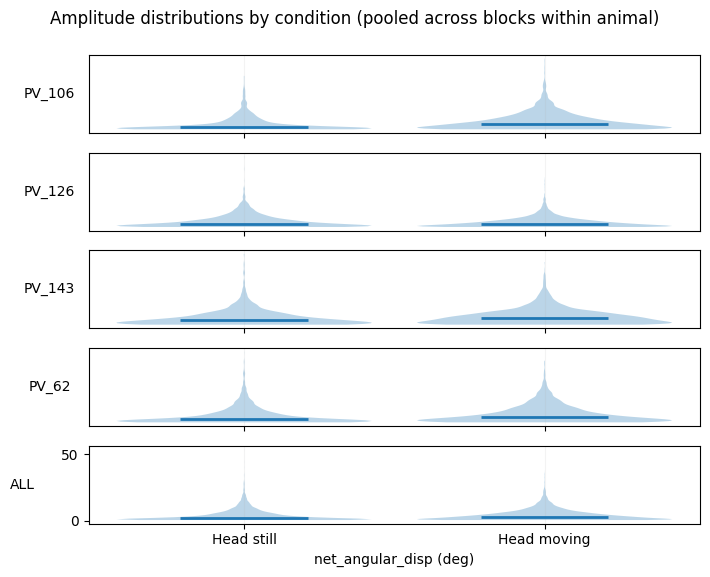

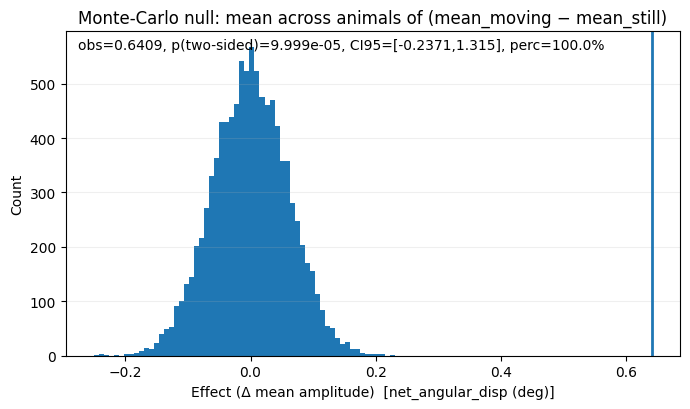

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


def mc_headmove_vs_amplitude(
    all_saccade_collection,
    amp_col="net_angular_disp",
    head_col="head_movement",
    animal_col="animal",
    block_col="block",              # only used for display / sanity; we pool across blocks within animal
    min_per_group=5,
    n_perm=5000,
    n_boot=2000,
    random_state=0,
    transform="none",               # "none" | "log1p" | "log10" (applies to plots + stats; keep "none" if you want degrees)
    show_progress=True,
    make_distribution_plots=True,
    make_null_plot=True,
    bins=60,
):
    """
    Monte-Carlo (permutation) test for difference in saccade amplitudes:
      moving vs still, shuffling labels WITHIN ANIMAL (across blocks pooled).

    Effect size (animal-level):
      For each animal: diff_a = mean(amp | moving) - mean(amp | still)
      Observed effect:  effect_obs = mean_a(diff_a)

    Null generation (Monte-Carlo):
      For each permutation:
        within each animal: shuffle labels (preserve #moving for that animal)
        recompute effect_perm
      p-value (two-sided): P(|effect_perm| >= |effect_obs|)

    Also returns bootstrap CI on effect_obs (resampling animals with replacement).
    """

    rng = np.random.default_rng(random_state)

    # -----------------------
    # 0) Validate + clean
    # -----------------------
    required = {amp_col, head_col, animal_col}
    missing = required - set(all_saccade_collection.columns)
    if missing:
        raise KeyError("Missing required columns: {}".format(missing))

    d = all_saccade_collection.loc[:, [animal_col, amp_col, head_col] + ([block_col] if block_col in all_saccade_collection.columns else [])].copy()
    d = d[d[amp_col].notna()].copy()
    d = d[np.isfinite(d[amp_col].astype(float))]
    d = d[d[head_col].notna()].copy()
    d = d[d[animal_col].notna()].copy()

    d[amp_col] = d[amp_col].astype(float)
    d[head_col] = d[head_col].astype(bool)

    # transform (optional) — applies to BOTH inference and plots
    y = d[amp_col].to_numpy()
    if transform == "none":
        d["_amp"] = y
        ylab = "{} (deg)".format(amp_col)
    elif transform == "log1p":
        d["_amp"] = np.log1p(np.clip(y, 0, None))
        ylab = "log1p({})".format(amp_col)
    elif transform == "log10":
        eps = 1e-12
        d["_amp"] = np.log10(np.clip(y, eps, None))
        ylab = "log10({})".format(amp_col)
    else:
        raise ValueError("transform must be one of: 'none', 'log1p', 'log10'")

    # -----------------------
    # 1) Build per-animal arrays
    # -----------------------
    animals = []
    amp_by_animal = {}
    nmove_by_animal = {}
    nstill_by_animal = {}
    diffs_obs = {}

    for a, ad in d.groupby(animal_col, sort=True):
        amps = ad["_amp"].to_numpy()
        labels = ad[head_col].to_numpy().astype(bool)

        n_move = int(labels.sum())
        n_still = int((~labels).sum())

        if n_move < min_per_group or n_still < min_per_group:
            continue

        animals.append(a)
        amp_by_animal[a] = amps
        nmove_by_animal[a] = n_move
        nstill_by_animal[a] = n_still

        diff_a = float(np.mean(amps[labels]) - np.mean(amps[~labels]))
        diffs_obs[a] = diff_a

    if len(animals) < 2:
        raise ValueError("Not enough animals with >= min_per_group in both conditions.")

    # observed animal-level effect
    diffs_obs_vec = np.array([diffs_obs[a] for a in animals], dtype=float)
    effect_obs = float(np.mean(diffs_obs_vec))

    # -----------------------
    # 2) Bootstrap CI over animals (effect size stability)
    # -----------------------
    boot = np.empty(n_boot, dtype=float)
    itb = range(n_boot)
    if show_progress:
        itb = tqdm(itb, desc="bootstrap_animals", leave=False)
    for i in itb:
        samp = rng.choice(len(animals), size=len(animals), replace=True)
        boot[i] = float(np.mean(diffs_obs_vec[samp]))

    ci95 = (float(np.nanpercentile(boot, 2.5)), float(np.nanpercentile(boot, 97.5)))

    # -----------------------
    # 3) Monte-Carlo shuffle within animal (null)
    # -----------------------
    null = np.empty(n_perm, dtype=float)
    itp = range(n_perm)
    if show_progress:
        itp = tqdm(itp, desc="permute_within_animal", leave=False)

    # speed: precompute indices 0..n-1 for each animal
    idx_by_animal = {a: np.arange(len(amp_by_animal[a])) for a in animals}

    for i in itp:
        diffs_i = []
        for a in animals:
            amps = amp_by_animal[a]
            idx = idx_by_animal[a]
            n_move = nmove_by_animal[a]

            perm = rng.permutation(idx)
            move_idx = perm[:n_move]
            still_idx = perm[n_move:]

            diffs_i.append(float(np.mean(amps[move_idx]) - np.mean(amps[still_idx])))

        null[i] = float(np.mean(diffs_i))

    # Monte-Carlo two-sided p-value
    p_two = float((np.sum(np.abs(null) >= abs(effect_obs)) + 1.0) / (len(null) + 1.0))

    # percentile location of observed value in null
    percentile = float(100.0 * np.mean(null < effect_obs))

    # -----------------------
    # 4) Plots
    # -----------------------
    figs = {}

    # (A) Distributions per animal + pooled
    if make_distribution_plots:
        nA = len(animals)
        # add one extra row for pooled
        fig_h = max(3.5, 1.15 * (nA + 1))
        fig, axes = plt.subplots(nA + 1, 1, figsize=(7.2, fig_h), sharex=True)

        # per animal
        for r, a in enumerate(animals):
            ad = d[d[animal_col] == a]
            y0 = ad.loc[~ad[head_col], "_amp"].to_numpy()
            y1 = ad.loc[ad[head_col], "_amp"].to_numpy()

            ax = axes[r]
            parts = ax.violinplot([y0, y1], positions=[1, 2], widths=0.85,
                                  showmeans=False, showmedians=True, showextrema=False)
            if "cmedians" in parts:
                parts["cmedians"].set_linewidth(2)
            ax.set_yticks([])
            ax.set_ylabel(str(a), rotation=0, labelpad=28, va="center")
            ax.grid(True, axis="x", alpha=0.15)

        # pooled
        ax = axes[-1]
        y0 = d.loc[~d[head_col], "_amp"].to_numpy()
        y1 = d.loc[d[head_col], "_amp"].to_numpy()
        parts = ax.violinplot([y0, y1], positions=[1, 2], widths=0.85,
                              showmeans=False, showmedians=True, showextrema=False)
        if "cmedians" in parts:
            parts["cmedians"].set_linewidth(2)
        ax.set_ylabel("ALL", rotation=0, labelpad=28, va="center")
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Head still", "Head moving"])
        ax.set_xlabel(ylab)
        ax.grid(True, axis="x", alpha=0.15)

        fig.suptitle("Amplitude distributions by condition (pooled across blocks within animal)", y=0.995)
        fig.tight_layout()
        figs["distributions"] = fig

    # (B) Null distribution with observed line
    if make_null_plot:
        fig, ax = plt.subplots(figsize=(7.0, 4.2))
        ax.hist(null, bins=bins)
        ax.axvline(effect_obs, linewidth=2)

        ax.set_title("Monte-Carlo null: mean across animals of (mean_moving − mean_still)")
        ax.set_xlabel("Effect (Δ mean amplitude)  [{}]".format(ylab))
        ax.set_ylabel("Count")
        ax.grid(True, axis="y", alpha=0.2)

        txt = "obs={:.4g}, p(two-sided)={:.4g}, CI95=[{:.4g},{:.4g}], perc={:.1f}%".format(
            effect_obs, p_two, ci95[0], ci95[1], percentile
        )
        ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top")

        fig.tight_layout()
        figs["null"] = fig

    # -----------------------
    # 5) Outputs
    # -----------------------
    per_animal_df = pd.DataFrame({
        animal_col: animals,
        "diff_mean_moving_minus_still": [diffs_obs[a] for a in animals],
        "n_moving": [nmove_by_animal[a] for a in animals],
        "n_still": [nstill_by_animal[a] for a in animals],
    })

    print("[MC] animals used: {} | effect(obs)={:.6g} | p(two-sided)={:.6g} | CI95=[{:.6g},{:.6g}] | percentile={:.2f}%".format(
        len(animals), effect_obs, p_two, ci95[0], ci95[1], percentile
    ))

    return {
        "config": dict(
            amp_col=amp_col, head_col=head_col, animal_col=animal_col,
            min_per_group=min_per_group, n_perm=n_perm, n_boot=n_boot,
            random_state=random_state, transform=transform
        ),
        "observed": dict(
            effect_mean_delta=effect_obs,
            ci95_bootstrap_animals=ci95,
            p_mc_two_sided=p_two,
            percentile_in_null=percentile
        ),
        "per_animal": per_animal_df,
        "null_dist": null,     # keep if you want to save/inspect; large array
        "bootstrap_dist": boot,
        "figures": figs
    }

out = mc_headmove_vs_amplitude(
    all_saccade_collection,
    amp_col="net_angular_disp",
    head_col="head_movement",
    animal_col="animal",
    block_col="block",
    n_perm=10000,
    n_boot=5000,
    random_state=42,
    transform="none",   # keep degrees for the reported effect
)

out["observed"]
out["per_animal"]
# If you made plots:
out["figures"]["distributions"].show()  # in notebooks just display(out["figures"]["distributions"])
out["figures"]["null"].show()


{'n': 23910, 'n_still': 9717, 'n_moving': 14193, 'mean_still': 3.9487763921092527, 'mean_moving': 4.400879539506507, 'std_still': 4.440916489078526, 'std_moving': 4.214318705111052, 'mannwhitney_U': 77149959.0, 'p_value': 4.582235754571453e-55, 'annotation': '****', 'transform': 'none', 'alpha': 0.05}


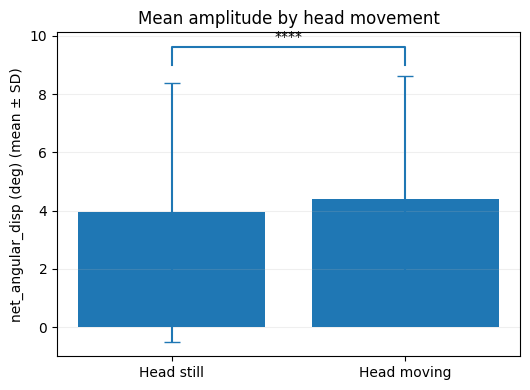

In [50]:
# This creates the bar plot for amplitudes given head movement or no head movement (Mann Whitney analysis for p-value)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def bar_mean_std_with_mannwhitney_star(
    all_saccade_collection,
    amp_col="net_angular_disp",
    head_col="head_movement",
    transform="none",          # "none" | "log10" | "log1p" (same as violin)
    ylim=None,
    title=None,
    star_mode="stars",         # "stars" or "p"
    alpha=0.05,
    save_path=None,
):
    """
    Simple 2-bar plot: mean ± std for still vs moving.
    Adds significance annotation using two-sided Mann–Whitney U.
    """
    # ---- clean ----
    needed = {amp_col, head_col}
    missing = needed - set(all_saccade_collection.columns)
    if missing:
        raise KeyError("Missing columns: {}".format(missing))

    d = all_saccade_collection.copy()
    d = d[d[amp_col].notna()].copy()
    d = d[np.isfinite(d[amp_col].astype(float))]
    d = d[d[head_col].notna()].copy()

    d[amp_col] = d[amp_col].astype(float)
    d[head_col] = d[head_col].astype(bool)

    # ---- transform ----
    y = d[amp_col].to_numpy()
    if transform == "none":
        y_plot = y
        ylab = "{} (deg)".format(amp_col)
    elif transform == "log10":
        eps = 1e-12
        y_plot = np.log10(np.clip(y, eps, None))
        ylab = "log10({})".format(amp_col)
    elif transform == "log1p":
        y_plot = np.log1p(np.clip(y, 0, None))
        ylab = "log1p({})".format(amp_col)
    else:
        raise ValueError("transform must be one of: 'none', 'log10', 'log1p'")

    d["_amp_plot"] = y_plot
    a0 = d.loc[~d[head_col], "_amp_plot"].to_numpy()  # still
    a1 = d.loc[d[head_col], "_amp_plot"].to_numpy()   # moving

    if len(a0) < 2 or len(a1) < 2:
        raise ValueError("Not enough samples in one of the groups to plot/compare.")

    # ---- stats ----
    U, p = stats.mannwhitneyu(a1, a0, alternative="two-sided")  # (moving vs still)
    m0, s0 = float(np.mean(a0)), float(np.std(a0, ddof=1))
    m1, s1 = float(np.mean(a1)), float(np.std(a1, ddof=1))

    def p_to_stars(pval):
        if pval < 1e-4:
            return "****"
        if pval < 1e-3:
            return "***"
        if pval < 1e-2:
            return "**"
        if pval < 5e-2:
            return "*"
        return "n.s."

    label = p_to_stars(p) if star_mode == "stars" else "p={:.3g}".format(p)

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(5.4, 4.0))
    x = np.array([0, 1], dtype=float)
    means = np.array([m0, m1])
    stds  = np.array([s0, s1])

    ax.bar(x, means)
    ax.errorbar(x, means, yerr=stds, fmt="none", capsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(["Head still", "Head moving"])
    ax.set_ylabel("{} (mean ± SD)".format(ylab))
    ax.set_title(title if title is not None else "Mean amplitude by head movement")

    if ylim is not None:
        ax.set_ylim(ylim)

    # ---- significance bracket ----
    y_top = np.max(means + stds)
    y_min, y_max = ax.get_ylim()
    h = 0.06 * (y_max - y_min)          # bracket height
    pad = 0.04 * (y_max - y_min)        # spacing above bars

    yb = y_top + pad
    ax.plot([x[0], x[0], x[1], x[1]], [yb, yb + h, yb + h, yb], linewidth=1.5)
    ax.text(np.mean(x), yb + h + 0.01 * (y_max - y_min), label, ha="center", va="bottom")

    ax.grid(True, axis="y", alpha=0.2)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300)

    out = dict(
        n=len(d),
        n_still=len(a0),
        n_moving=len(a1),
        mean_still=m0,
        mean_moving=m1,
        std_still=s0,
        std_moving=s1,
        mannwhitney_U=float(U),
        p_value=float(p),
        annotation=label,
        transform=transform,
        alpha=alpha,
    )
    return fig, ax, out


fig, ax, stats_out = bar_mean_std_with_mannwhitney_star(
    all_saccade_collection,
    amp_col="net_angular_disp",
    head_col="head_movement",
    transform="none",
    star_mode="stars",
)
print(stats_out)
plt.show()


In [23]:
# now get saccade frequency accoreding to state annotations:
def read_behavior_state(block):
    """
    Reads the behavior_state CSV file from the block's analysis folder and assigns it to the block object.

    Args:
        block (BlockSync): The block object containing metadata about the analysis folder.

    Returns:
        pd.DataFrame: The loaded behavior state dataframe.
    """
    try:
        # Construct the path to the CSV file
        csv_path = block.analysis_path / f"block_{block.block_num}_behavior_state.csv"

        if not csv_path.exists():
            raise FileNotFoundError(f"No behavior_state file found at {csv_path}")

        # Read the CSV into a DataFrame
        behavior_state_df = pd.read_csv(csv_path)

        # Assign it to the block object for easy access
        block.behavior_state = behavior_state_df
        print(f"Behavior state successfully loaded from {csv_path}")

        return behavior_state_df

    except Exception as e:
        print(f"Error reading behavior state: {e}")
        return None

for block in block_collection:
    read_behavior_state(block)



Behavior state successfully loaded from Z:\Nimrod\experiments\PV_106\2025_08_06\block_008\analysis\block_008_behavior_state.csv
Behavior state successfully loaded from Z:\Nimrod\experiments\PV_106\2025_08_06\block_009\analysis\block_009_behavior_state.csv
Behavior state successfully loaded from Z:\Nimrod\experiments\PV_106\2025_08_06\block_010\analysis\block_010_behavior_state.csv
Behavior state successfully loaded from Z:\Nimrod\experiments\PV_106\2025_08_06\block_011\analysis\block_011_behavior_state.csv
Behavior state successfully loaded from Z:\Nimrod\experiments\PV_106\2025_08_06\block_012\analysis\block_012_behavior_state.csv
Behavior state successfully loaded from Z:\Nimrod\experiments\PV_143\2025_08_25\block_001\analysis\block_001_behavior_state.csv
Behavior state successfully loaded from Z:\Nimrod\experiments\PV_143\2025_08_25\block_002\analysis\block_002_behavior_state.csv
Behavior state successfully loaded from Z:\Nimrod\experiments\PV_143\2025_08_25\block_003\analysis\block

In [24]:
def collect_behavior_state_from_blocks(block_collection):
    """
    Collects block.behavior_state dataframes into one long dataframe with animal + block identifiers.

    Expects each block has:
      - block.behavior_state (df with columns: start_time, end_time, annotation)
      - block.block_num
      - block.animal (or block.animal_id). If neither exists, you can patch below.
    """
    rows = []
    for block in block_collection:
        if not hasattr(block, "behavior_state") or block.behavior_state is None:
            continue

        bdf = block.behavior_state.copy()

        # --- infer animal id attribute name ---
        if hasattr(block, "animal_call"):
            animal = block.animal_call
        elif hasattr(block, "animal_id"):
            animal = block.animal_id
        else:
            raise AttributeError("Block has no 'animal' or 'animal_id' attribute. Patch this in collect_behavior_state_from_blocks().")

        block_num = getattr(block, "block_num", None)
        if block_num is None:
            raise AttributeError("Block has no 'block_num' attribute.")

        bdf["animal"] = animal
        bdf["block"] = block_num
        rows.append(bdf)

    if not rows:
        return pd.DataFrame(columns=["animal", "block", "start_time", "end_time", "annotation"])

    out = pd.concat(rows, ignore_index=True)
    return out

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


def mc_saccade_rate_by_behavior_state(
    all_saccade_collection,
    behavior_state_all,                  # dataframe with animal, block, start_time, end_time, annotation
    onset_col="t_onset_ms",              # change to your saccade onset timestamp column (ms)
    animal_col="animal",
    block_col="block",
    state_col="annotation",              # "active"/"quiet"
    start_col="start_time",
    end_col="end_time",
    head_col="head_movement",            # optional (only used if head_filter != "all")
    head_filter="all",                   # "all" | "moving" | "still"
    bin_size_ms=1000,                    # 1s bins (recommended for rate)
    min_total_time_s=10.0,               # per animal: require >= this much labeled time in EACH state
    n_perm=10000,
    n_boot=5000,
    random_state=0,
    show_progress=True,
    make_plots=True,
    bins_null=70,
):
    """
    Monte-Carlo within-animal shuffle test on saccade rate difference between behavioral states.

    Key idea:
      - Convert overlapping behavior windows into disjoint time bins (bin_size_ms).
      - Assign each bin a state by max overlap duration with active vs quiet windows.
      - Count saccades per bin (optionally filtered by head movement).
      - For each animal: rate_active = total_sacc_active / total_time_active, same for quiet.
      - Effect per animal: diff_a = rate_active - rate_quiet
      - Observed effect: mean_a(diff_a)

    Null:
      - Shuffle bin labels within each animal (across blocks pooled), preserving #bins per state.
      - Recompute effect. Compare observed to null for p-value.
    """
    rng = np.random.default_rng(random_state)

    # -----------------------
    # 0) Validate inputs
    # -----------------------
    req_sacc = {animal_col, block_col, onset_col}
    missing = req_sacc - set(all_saccade_collection.columns)
    if missing:
        raise KeyError("Missing columns in all_saccade_collection: {}".format(missing))

    req_beh = {animal_col, block_col, start_col, end_col, state_col}
    missing = req_beh - set(behavior_state_all.columns)
    if missing:
        raise KeyError("Missing columns in behavior_state_all: {}".format(missing))

    sacc = all_saccade_collection.copy()
    beh = behavior_state_all.copy()

    # filter saccades by head movement if requested
    if head_filter != "all":
        if head_col not in sacc.columns:
            raise KeyError("head_filter='{}' requested, but '{}' not found in all_saccade_collection".format(head_filter, head_col))
        sacc = sacc[sacc[head_col].notna()].copy()
        sacc[head_col] = sacc[head_col].astype(bool)
        if head_filter == "moving":
            sacc = sacc[sacc[head_col]]
        elif head_filter == "still":
            sacc = sacc[~sacc[head_col]]
        else:
            raise ValueError("head_filter must be 'all', 'moving', or 'still'")

    # keep only relevant behavior states
    beh = beh[beh[state_col].isin(["active", "quiet"])].copy()

    # -----------------------
    # 1) Build bin-level table: (animal, block, bin_start, state, n_sacc)
    #    Overlaps handled by max-overlap vote per bin.
    # -----------------------
    # index saccades by (animal, block) for fast access
    sacc = sacc[sacc[onset_col].notna()].copy()
    sacc[onset_col] = sacc[onset_col].astype(float)

    sacc_groups = {}
    for (a, b), sd in sacc.groupby([animal_col, block_col], sort=False):
        sacc_groups[(a, b)] = sd[onset_col].to_numpy()

    bin_rows = []

    gb = beh.groupby([animal_col, block_col], sort=False)

    it_blocks = gb
    if show_progress:
        it_blocks = tqdm(list(gb), desc="binning_behavior", leave=False)

    for (a, b), bd in it_blocks:
        # define bin range
        t0 = float(np.nanmin(bd[start_col].to_numpy()))
        t1 = float(np.nanmax(bd[end_col].to_numpy()))
        if not np.isfinite(t0) or not np.isfinite(t1) or t1 <= t0:
            continue

        # bin edges
        bin_starts = np.arange(np.floor(t0 / bin_size_ms) * bin_size_ms,
                               np.ceil(t1 / bin_size_ms) * bin_size_ms,
                               bin_size_ms)

        # gather saccade times for this block (if none, array empty)
        ts = sacc_groups.get((a, b), np.array([], dtype=float))
        # for fast counting, sort (should already be mostly sorted)
        ts = np.sort(ts)

        # for each bin, assign state by overlap-duration vote
        # pre-split windows by label
        w_active = bd.loc[bd[state_col] == "active", [start_col, end_col]].to_numpy(dtype=float)
        w_quiet  = bd.loc[bd[state_col] == "quiet",  [start_col, end_col]].to_numpy(dtype=float)

        # helper to compute total overlap between a bin [bs, be] and windows list
        def total_overlap(windows, bs, be):
            if windows.size == 0:
                return 0.0
            # overlap per window: max(0, min(end,be) - max(start,bs))
            lo = np.maximum(windows[:, 0], bs)
            hi = np.minimum(windows[:, 1], be)
            return float(np.sum(np.clip(hi - lo, 0.0, None)))

        # two-pointer saccade counts per bin
        j0 = 0
        n_ts = len(ts)

        for bs in bin_starts:
            be = bs + bin_size_ms

            oa = total_overlap(w_active, bs, be)
            oq = total_overlap(w_quiet,  bs, be)

            # if neither label covers the bin, skip it
            if oa <= 0 and oq <= 0:
                continue

            state = "active" if oa > oq else "quiet"  # tie -> quiet (deterministic)
            # count saccades with onset in [bs, be)
            while j0 < n_ts and ts[j0] < bs:
                j0 += 1
            j1 = j0
            while j1 < n_ts and ts[j1] < be:
                j1 += 1
            n_s = int(j1 - j0)

            bin_rows.append((a, b, float(bs), state, n_s))

    if not bin_rows:
        raise ValueError("No binned behavior data created. Check behavior_state_all coverage and block identifiers.")

    bins_df = pd.DataFrame(bin_rows, columns=[animal_col, block_col, "bin_start_ms", "state", "n_sacc"])
    bins_df["bin_dur_s"] = bin_size_ms / 1000.0

    # -----------------------
    # 2) Compute observed per-animal rate difference
    # -----------------------
    animals = []
    diff_obs = []
    per_animal_rows = []

    for a, ad in bins_df.groupby(animal_col, sort=True):
        # total time per state
        t_active = float(ad.loc[ad["state"] == "active", "bin_dur_s"].sum())
        t_quiet  = float(ad.loc[ad["state"] == "quiet",  "bin_dur_s"].sum())

        if t_active < min_total_time_s or t_quiet < min_total_time_s:
            continue

        n_active = int(ad.loc[ad["state"] == "active", "n_sacc"].sum())
        n_quiet  = int(ad.loc[ad["state"] == "quiet",  "n_sacc"].sum())

        r_active = n_active / t_active
        r_quiet  = n_quiet  / t_quiet
        dlt = float(r_active - r_quiet)

        animals.append(a)
        diff_obs.append(dlt)
        per_animal_rows.append(dict(
            animal=a,
            rate_active_hz=r_active,
            rate_quiet_hz=r_quiet,
            diff_hz=dlt,
            time_active_s=t_active,
            time_quiet_s=t_quiet,
            n_sacc_active=n_active,
            n_sacc_quiet=n_quiet
        ))

    if len(animals) < 2:
        raise ValueError("Not enough animals pass min_total_time_s in BOTH states. Lower min_total_time_s or check annotations.")

    diff_obs = np.array(diff_obs, dtype=float)
    effect_obs = float(np.mean(diff_obs))

    per_animal_df = pd.DataFrame(per_animal_rows).sort_values("animal")

    # -----------------------
    # 3) Bootstrap CI over animals
    # -----------------------
    boot = np.empty(n_boot, dtype=float)
    itb = range(n_boot)
    if show_progress:
        itb = tqdm(itb, desc="bootstrap_animals", leave=False)
    for i in itb:
        idx = rng.integers(0, len(diff_obs), size=len(diff_obs))
        boot[i] = float(np.mean(diff_obs[idx]))
    ci95 = (float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5)))

    # -----------------------
    # 4) Monte-Carlo shuffle within animal (across blocks pooled)
    # -----------------------
    # Pre-pack each animal’s bins as arrays of counts + labels
    pack = {}
    for a in animals:
        ad = bins_df[bins_df[animal_col] == a]
        counts = ad["n_sacc"].to_numpy(dtype=float)
        labels = (ad["state"].to_numpy() == "active")  # True=active, False=quiet
        # durations are constant per bin; total time is bin_dur_s * n_bins_state
        pack[a] = (counts, labels)

    null = np.empty(n_perm, dtype=float)
    itp = range(n_perm)
    if show_progress:
        itp = tqdm(itp, desc="permute_within_animal", leave=False)

    for i in itp:
        diffs_i = []
        for a in animals:
            counts, labels = pack[a]
            n_active_bins = int(labels.sum())
            n_bins = len(labels)

            perm = rng.permutation(n_bins)
            active_mask = np.zeros(n_bins, dtype=bool)
            active_mask[perm[:n_active_bins]] = True

            n_active = float(counts[active_mask].sum())
            n_quiet  = float(counts[~active_mask].sum())

            t_active = (n_active_bins * bin_size_ms) / 1000.0
            t_quiet  = ((n_bins - n_active_bins) * bin_size_ms) / 1000.0

            r_active = n_active / t_active
            r_quiet  = n_quiet  / t_quiet
            diffs_i.append(r_active - r_quiet)

        null[i] = float(np.mean(diffs_i))

    p_two = float((np.sum(np.abs(null) >= abs(effect_obs)) + 1.0) / (len(null) + 1.0))
    percentile = float(100.0 * np.mean(null < effect_obs))

    # -----------------------
    # 5) Plots
    # -----------------------
    figs = {}

    if make_plots:
        # null distribution plot
        fig, ax = plt.subplots(figsize=(7.0, 4.2))
        ax.hist(null, bins=bins_null)
        ax.axvline(effect_obs, linewidth=2)
        ax.set_title("Monte-Carlo null: animal-mean Δrate (active − quiet)")
        ax.set_xlabel("Δ rate (Hz)")
        ax.set_ylabel("Count")
        ax.grid(True, axis="y", alpha=0.2)
        ax.text(
            0.02, 0.98,
            "obs={:.4g} Hz, p(two-sided)={:.4g}, CI95=[{:.4g},{:.4g}] Hz, perc={:.1f}%\nanimals={}".format(
                effect_obs, p_two, ci95[0], ci95[1], percentile, len(animals)
            ),
            transform=ax.transAxes, va="top"
        )
        fig.tight_layout()
        figs["null"] = fig

    print("[MC-rate] animals used: {} | effect(obs)={:.6g} Hz | p(two-sided)={:.6g} | CI95=[{:.6g},{:.6g}] Hz | percentile={:.2f}% | head_filter={}".format(
        len(animals), effect_obs, p_two, ci95[0], ci95[1], percentile, head_filter
    ))

    return {
        "config": dict(
            onset_col=onset_col, bin_size_ms=bin_size_ms, head_filter=head_filter,
            n_perm=n_perm, n_boot=n_boot, random_state=random_state,
            min_total_time_s=min_total_time_s
        ),
        "observed": dict(
            effect_mean_delta_rate_hz=effect_obs,
            ci95_bootstrap_animals_hz=ci95,
            p_mc_two_sided=p_two,
            percentile_in_null=percentile
        ),
        "per_animal": per_animal_df,
        "bins_df": bins_df,          # useful for QC plots later
        "null_dist": null,
        "bootstrap_dist": boot,
        "figures": figs
    }


binning_behavior:   0%|          | 0/22 [00:00<?, ?it/s]

bootstrap_animals:   0%|          | 0/5000 [00:00<?, ?it/s]

permute_within_animal:   0%|          | 0/10000 [00:00<?, ?it/s]

[MC-rate] animals used: 5 | effect(obs)=2.66243 Hz | p(two-sided)=9.999e-05 | CI95=[1.28425,3.77065] Hz | percentile=100.00% | head_filter=all


,animal,rate_active_hz,rate_quiet_hz,diff_hz,time_active_s,time_quiet_s,n_sacc_active,n_sacc_quiet
0,PV_106,3.762500,0.730820,3.031680,560.0,6074.0,2107,4439
1,PV_126,4.695067,0.302327,4.392740,892.0,12589.0,4188,3806
2,PV_143,3.116279,0.472911,2.643368,258.0,5039.0,804,2383
3,PV_57,2.379913,2.260624,0.119289,687.0,4071.0,1635,9203
4,PV_62,3.800000,0.674932,3.125068,125.0,3307.0,475,2232


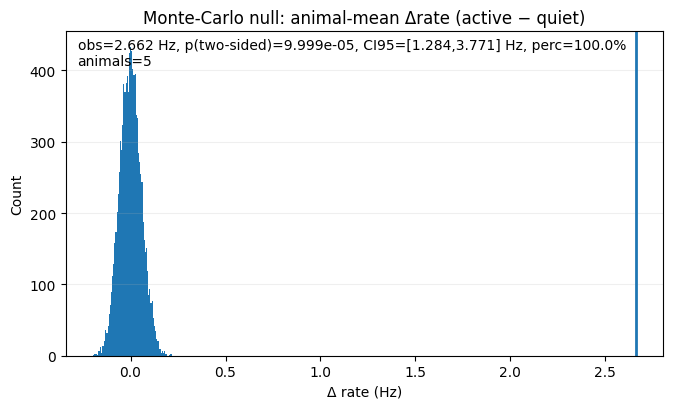

In [64]:
behavior_state_all = collect_behavior_state_from_blocks(block_collection)
out_rate = mc_saccade_rate_by_behavior_state(
    all_saccade_collection=all_saccade_collection,
    behavior_state_all=behavior_state_all,
    onset_col="saccade_on_ms",     # <-- change if your column differs
    head_filter="all",
    bin_size_ms=1000,
    n_perm=10000,
    n_boot=5000,
    random_state=42
)

out_rate["observed"]
out_rate["per_animal"]


Overall span (animal means): main-axis = 34.99 ± 7.33 deg; perp-axis = 26.07 ± 6.35 deg (n=5)
Exported scatter + data bundle to: Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\supplementary\total_oculomotor_span_main_perp_2025_12_25_23_07_06


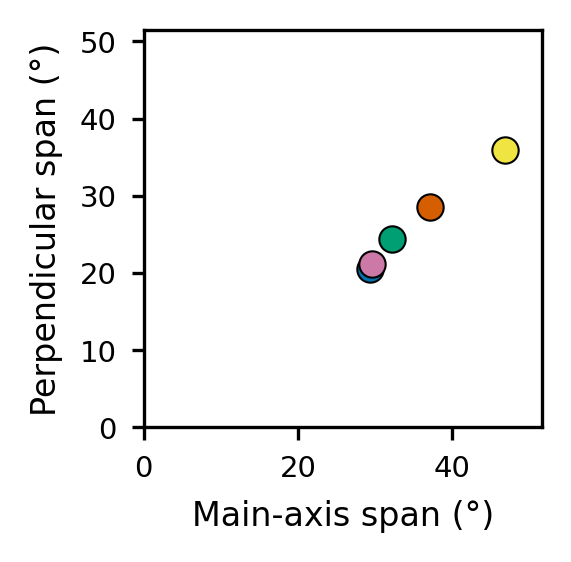

(        main_span_mean  perp_span_mean  main_span_left  perp_span_left  \
 animal                                                                   
 PV_106       29.285904       20.453498       31.527287       23.228371   
 PV_126       37.091016       28.477140       30.742978       30.451299   
 PV_143       32.120833       24.339585       28.672151       25.409229   
 PV_57        29.616425       21.160760       25.183234       17.382197   
 PV_62        46.857100       35.921056       54.916659       34.048014   
 
         main_span_right  perp_span_right  
 animal                                    
 PV_106        27.044521        17.678625  
 PV_126        43.439054        26.502982  
 PV_143        35.569515        23.269941  
 PV_57         34.049616        24.939324  
 PV_62         38.797542        37.794097  ,
 {'n_animals': 5,
  'main_axis_mean_deg': 34.994255846336436,
  'main_axis_std_deg': 7.329501601351639,
  'perp_axis_mean_deg': 26.070407899399612,
  'perp_axis_std

In [32]:
# final span plot version:
import os, re, math, pickle, datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# Color utilities
# =========================
COLOR_TEMPLATES = {
    "okabeito": ["#0072B2", "#D55E00", "#009E73", "#CC79A7",
                 "#F0E442", "#56B4E9", "#E69F00", "#000000"],
    "tableau10": [plt.get_cmap("tab10")(i) for i in range(10)],
}

def build_color_map(labels, template="okabeito", custom=None, order=None):
    labs = list(order) if order is not None else list(labels)
    base = list(custom) if custom is not None else list(COLOR_TEMPLATES.get(template, COLOR_TEMPLATES["okabeito"]))
    return {lab: base[i % len(base)] for i, lab in enumerate(labs)}


def compare_animals_total_oculomotor_span(
    block_dict,
    saccade_collection,
    outlier_percentiles=(2.5, 97.5),
    export_path=None,
    min_samples=200,
    num_angle_bins=72,
    template="okabeito",
    figsize=(3.0, 3.0),
    print_overall_stats=True,
):
    """
    Compute per-animal oculomotor span along:
      - a data-defined main axis
      - its perpendicular axis

    Plot:
      - single-panel scatter (one point per animal):
          x = main_span_mean (mean across available eyes)
          y = perp_span_mean (mean across available eyes)

    Also computes overall mean±std across animals for main/perp spans
    (based on the per-animal means).
    """
    low_q, high_q = outlier_percentiles
    if num_angle_bins % 2 != 0:
        raise ValueError(f"num_angle_bins must be even, got {num_angle_bins}")

    # ---------------- helpers ----------------
    def _clean_angles_deg(angles):
        arr = np.asarray(angles, dtype=float)
        return np.mod(arr, 360.0)

    def _hist_deg(angles_deg, num_bins):
        edges = np.linspace(0.0, 360.0, num_bins + 1)
        counts, edges = np.histogram(angles_deg, bins=edges)
        total = counts.sum()
        density = counts / total if total > 0 else counts.astype(float)
        centers = 0.5 * (edges[:-1] + edges[1:])
        return density, edges, centers

    def _preferred_axis_orientation_deg(density, centers):
        # axis folding into [0,180)
        if density.size % 2 != 0:
            raise ValueError("Number of angle bins must be even for axis folding.")
        half = density.size // 2
        axis_density = density[:half] + density[half:]
        axis_centers = centers[:half]
        if axis_density.sum() == 0:
            return 0.0
        idx_peak = int(np.nanargmax(axis_density))
        return float(axis_centers[idx_peak])

    def _shortest_axis_rotation_deg(axis_center_deg):
        axis_center_deg = float(axis_center_deg) % 180.0
        d1 = -axis_center_deg
        d2 = 180.0 - axis_center_deg
        return d1 if abs(d1) <= abs(d2) else d2

    def _rotate_coords(x, y, rot_deg):
        th = math.radians(rot_deg)
        c, s = math.cos(th), math.sin(th)
        xr = c * x - s * y
        yr = s * x + c * y
        return xr, yr

    # ---------------- 1. saccade-defined axes per animal × eye ----------------
    required_cols = {"animal", "eye", "overall_angle_deg"}
    missing = required_cols.difference(saccade_collection.columns)
    if missing:
        raise ValueError(f"saccade_collection is missing required columns: {missing}")

    animals_in_sacc = saccade_collection["animal"].dropna().unique()
    sacc_axis_info = {}  # (animal, 'left'/'right') -> dict

    for animal in animals_in_sacc:
        for eye_code, eye_label in (("L", "left"), ("R", "right")):
            df_eye = saccade_collection.query("animal == @animal and eye == @eye_code")
            if df_eye.empty:
                continue
            ang = _clean_angles_deg(df_eye["overall_angle_deg"].values)
            if ang.size == 0:
                continue
            dens, _, centers = _hist_deg(ang, num_angle_bins)
            axis_center = _preferred_axis_orientation_deg(dens, centers)
            rot_deg = _shortest_axis_rotation_deg(axis_center)
            sacc_axis_info[(animal, eye_label)] = dict(
                axis_center_deg_sacc=axis_center,
                rotation_deg_sacc=rot_deg,
                n_saccades=len(ang),
            )

    # ---------------- 2. collect gaze per animal × eye ----------------
    gaze_data = defaultdict(lambda: {"left_x": [], "left_y": [], "right_x": [], "right_y": []})

    for key, block in block_dict.items():
        m = re.match(r"^(PV_\d+)", str(key))
        if not m:
            continue
        animal = m.group(1)

        dfL = getattr(block, "left_eye_data_centered", None)
        if dfL is not None and {"k_theta", "k_phi"} <= set(dfL.columns):
            x = pd.to_numeric(dfL["k_theta"], errors="coerce")
            y = pd.to_numeric(dfL["k_phi"], errors="coerce")
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.any():
                gaze_data[animal]["left_x"].append(x[mask].values)
                gaze_data[animal]["left_y"].append(y[mask].values)

        dfR = getattr(block, "right_eye_data_centered", None)
        if dfR is not None and {"k_theta", "k_phi"} <= set(dfR.columns):
            x = pd.to_numeric(dfR["k_theta"], errors="coerce")
            y = pd.to_numeric(dfR["k_phi"], errors="coerce")
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.any():
                gaze_data[animal]["right_x"].append(x[mask].values)
                gaze_data[animal]["right_y"].append(y[mask].values)

    # ---------------- 3. per-eye spans in main/perp axes ----------------
    per_eye_span = defaultdict(lambda: {"left": None, "right": None})

    for animal, comp in gaze_data.items():
        for eye_label in ["left", "right"]:
            sinfo = sacc_axis_info.get((animal, eye_label))
            if sinfo is None:
                continue

            x_chunks = comp[f"{eye_label}_x"]
            y_chunks = comp[f"{eye_label}_y"]
            if not x_chunks or not y_chunks:
                continue

            x_all = np.concatenate(x_chunks)
            y_all = np.concatenate(y_chunks)
            mask = np.isfinite(x_all) & np.isfinite(y_all)
            x_all = x_all[mask]
            y_all = y_all[mask]

            n_gaze = len(x_all)
            if n_gaze < min_samples:
                print(f"[{eye_label} eye] Skipping {animal}: only {n_gaze} gaze samples (< {min_samples}).")
                continue

            rot_deg_sacc = sinfo["rotation_deg_sacc"]
            axis_center_sacc = sinfo["axis_center_deg_sacc"]
            u_raw, v_raw = _rotate_coords(x_all, y_all, rot_deg_sacc)

            # spans along rotated axes (central percentiles)
            u_min_raw = float(np.nanpercentile(u_raw, low_q))
            u_max_raw = float(np.nanpercentile(u_raw, high_q))
            v_min_raw = float(np.nanpercentile(v_raw, low_q))
            v_max_raw = float(np.nanpercentile(v_raw, high_q))
            u_span_raw = u_max_raw - u_min_raw
            v_span_raw = v_max_raw - v_min_raw

            # choose main vs perp by span
            if v_span_raw > u_span_raw:
                main_span_eye = v_span_raw
                perp_span_eye = u_span_raw
                effective_axis_center = (axis_center_sacc + 90.0) % 180.0
                effective_rotation_deg = rot_deg_sacc + 90.0
                axis_swapped = True
            else:
                main_span_eye = u_span_raw
                perp_span_eye = v_span_raw
                effective_axis_center = axis_center_sacc
                effective_rotation_deg = rot_deg_sacc
                axis_swapped = False

            per_eye_span[animal][eye_label] = dict(
                main_span=main_span_eye,
                perp_span=perp_span_eye,
                u_span_raw=u_span_raw,
                v_span_raw=v_span_raw,
                axis_center_deg_sacc=axis_center_sacc,
                rotation_deg_sacc=rot_deg_sacc,
                effective_axis_center_deg=effective_axis_center,
                effective_rotation_deg=effective_rotation_deg,
                axis_swapped=axis_swapped,
                n_gaze=n_gaze,
                n_saccades=sinfo["n_saccades"],
            )

    # ---------------- 4. per-animal average across eyes ----------------
    rows = []
    for animal, eyes in per_eye_span.items():
        spans_main = []
        spans_perp = []
        left_main = np.nan
        left_perp = np.nan
        right_main = np.nan
        right_perp = np.nan

        if eyes["left"] is not None:
            left_main = eyes["left"]["main_span"]
            left_perp = eyes["left"]["perp_span"]
            spans_main.append(left_main)
            spans_perp.append(left_perp)
        if eyes["right"] is not None:
            right_main = eyes["right"]["main_span"]
            right_perp = eyes["right"]["perp_span"]
            spans_main.append(right_main)
            spans_perp.append(right_perp)

        if not spans_main:
            continue

        rows.append(dict(
            animal=animal,
            main_span_mean=float(np.mean(spans_main)),
            perp_span_mean=float(np.mean(spans_perp)),
            main_span_left=left_main,
            perp_span_left=left_perp,
            main_span_right=right_main,
            perp_span_right=right_perp,
        ))

    if not rows:
        print("No animals with valid spans.")
        return pd.DataFrame(), {}, None, None

    span_summary_df = pd.DataFrame(rows).set_index("animal").sort_index()

    # ---------------- 4b. overall stats across animals ----------------
    main_vals = span_summary_df["main_span_mean"].to_numpy(dtype=float)
    perp_vals = span_summary_df["perp_span_mean"].to_numpy(dtype=float)
    n_animals = int(np.isfinite(main_vals).sum())  # should match df rows in practice

    def _std_ddof1(x):
        x = x[np.isfinite(x)]
        if x.size <= 1:
            return float("nan")
        return float(np.std(x, ddof=1))

    overall_stats = dict(
        n_animals=int(span_summary_df.shape[0]),
        main_axis_mean_deg=float(np.nanmean(main_vals)),
        main_axis_std_deg=_std_ddof1(main_vals),
        perp_axis_mean_deg=float(np.nanmean(perp_vals)),
        perp_axis_std_deg=_std_ddof1(perp_vals),
    )

    if print_overall_stats:
        print(
            "Overall span (animal means): "
            f"main-axis = {overall_stats['main_axis_mean_deg']:.2f} ± {overall_stats['main_axis_std_deg']:.2f} deg; "
            f"perp-axis = {overall_stats['perp_axis_mean_deg']:.2f} ± {overall_stats['perp_axis_std_deg']:.2f} deg "
            f"(n={overall_stats['n_animals']})"
        )

    # ---------------- 5. plot: scatter only (NO std/error bars) ----------------
    animals = span_summary_df.index.tolist()
    color_map = build_color_map(animals, template=template, order=animals)

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    x_vals = span_summary_df["main_span_mean"].values
    y_vals = span_summary_df["perp_span_mean"].values
    max_x = float(np.nanmax(x_vals)) if x_vals.size else 1.0
    max_y = float(np.nanmax(y_vals)) if y_vals.size else 1.0
    lim = max(max_x, max_y) * 1.1

    for animal in animals:
        row = span_summary_df.loc[animal]
        ax.scatter(
            row["main_span_mean"], row["perp_span_mean"],
            s=40,
            color=color_map[animal],
            edgecolor="black",
            linewidth=0.5,
            label=animal,
        )

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("Main-axis span (°)", fontsize=8)
    ax.set_ylabel("Perpendicular span (°)", fontsize=8)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis="both", labelsize=7, direction="out", length=3, width=0.8)

    #handles, labels = ax.get_legend_handles_labels()
    #ax.legend(handles, labels, fontsize=7, frameon=False, title="Animal", title_fontsize=8)

    fig.tight_layout()

    # ---------------- 6. optional export ----------------
    if export_path is not None:
        ts = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
        outdir = os.path.join(str(export_path), f"total_oculomotor_span_main_perp_{ts}")
        os.makedirs(outdir, exist_ok=True)

        pdf_file = os.path.join(outdir, "total_oculomotor_span_main_perp_scatter.pdf")
        fig.savefig(pdf_file, format="pdf", bbox_inches="tight", dpi=300)

        per_eye_span_plain = {animal: dict(eyes) for animal, eyes in per_eye_span.items()}

        data_file = os.path.join(outdir, "total_oculomotor_span_main_perp_scatter.pkl")
        with open(data_file, "wb") as f:
            pickle.dump(
                dict(
                    span_summary_df=span_summary_df,
                    overall_stats=overall_stats,
                    per_eye_span=per_eye_span_plain,
                    sacc_axis_info=sacc_axis_info,
                    outlier_percentiles=outlier_percentiles,
                    min_samples=min_samples,
                    num_angle_bins=num_angle_bins,
                ),
                f,
            )

        print(f"Exported scatter + data bundle to: {outdir}")

    plt.show()

    return span_summary_df, overall_stats, fig, ax

export_path = r'Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\supplementary'
compare_animals_total_oculomotor_span(
    block_dict,
    saccade_collection,
    outlier_percentiles=(2.5, 97.5),
    export_path=export_path,
    min_samples=200,
    num_angle_bins=72,
    template="okabeito",
    figsize=(2, 2))

In [41]:
# monocular saccade analysis
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pathlib
import tqdm
import pandas as pd
import datetime

plt.style.use('default')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42

def plot_right_vs_left_eye_hist2d_twopanels(
    all_saccade_collection, block_dict, export_path=None,
    iqr_multiplier=1.5, bins=100,
    macro_range=(0, 2.0), micro_range=(0, 0.25),
    macro_n_ticks=6, micro_n_ticks=6,
    macro_tick_list=None, micro_tick_list=None,
    # --- new controls ---
    event_mode="all",                   # "all" | "monocular" | "binocular"
    pair_merge_ms=60,                   # collapse L/R duplicate binocular pairs
    contra_event_window_ms=60,          # classify binocular if contra onset within ±this of ipsi onset
    contra_sample_ms=51,                # window to compute contra max (visualization only)
    frame_period_local=True             # robust per-event frame period or global median
):
    """
    Two-panel 2D histograms of Right vs Left peak angular speed (deg/ms).
    Key improvements:
      * Monocular/binocular classification uses contra-eye saccade tables.
      * Optional merging of duplicate binocular L/R pairs to remove diagonal ridge.
      * Contra peak is only sampled after the event-mode filter.
    """

    # -------- helpers --------
    def estimate_frame_period_ms(eye_df, t_ms):
        if not frame_period_local:
            diffs_global = np.diff(eye_df['ms_axis'].values)
            fp_global = np.nanmedian(diffs_global[np.isfinite(diffs_global)])
            return fp_global if (np.isfinite(fp_global) and fp_global > 0) else 17.0
        try:
            window = eye_df.query('ms_axis >= @t_ms - 51 and ms_axis <= @t_ms + 51')['ms_axis'].values
            if window.size >= 3:
                diffs = np.diff(np.sort(window))
                fp = np.nanmedian(diffs)
                if np.isfinite(fp) and fp > 0:
                    return fp
        except Exception:
            pass
        diffs_global = np.diff(eye_df['ms_axis'].values)
        fp_global = np.nanmedian(diffs_global[np.isfinite(diffs_global)])
        return fp_global if (np.isfinite(fp_global) and fp_global > 0) else 17.0

    def contra_has_event(block, eye, t_ms, win_ms):
        if eye == 'L':
            sdf = getattr(block, 'r_saccade_df', None)
        else:
            sdf = getattr(block, 'l_saccade_df', None)
        if sdf is None or 'saccade_on_ms' not in sdf.columns:
            return False, np.nan
        # nearest contra onset
        idx = np.argmin(np.abs(sdf['saccade_on_ms'].values - t_ms)) if len(sdf) else None
        if idx is None: return False, np.nan
        nearest = sdf['saccade_on_ms'].values[idx]
        return (abs(nearest - t_ms) <= win_ms), nearest

    def sample_contra_peak(contra_df, t_ms, halfwin_ms, frame_ms):
        series = contra_df.query('ms_axis >= @t_ms - @halfwin_ms and ms_axis <= @t_ms + @halfwin_ms')['angular_speed_r']
        if series.notna().sum() == 0:
            return np.nan
        return float(np.nanmax(series.values)) / frame_ms  # deg/frame -> deg/ms

    # -------- collect points --------
    right_eye_speeds, left_eye_speeds, animals_for_weights = [], [], []
    # For binocular de-duplication
    seen_pairs = set()

    # IMPORTANT: work on a copy to avoid chained assignment surprises
    rows = all_saccade_collection.copy()

    for _, row in tqdm.tqdm(rows.iterrows(), total=len(rows)):
        # Block lookup
        block_key = f"{row['animal']}_block_{row['block']}"
        block = block_dict.get(block_key, None)
        if block is None:
            continue

        eye = row['eye']
        t0 = float(row['saccade_on_ms'])

        # choose ipsi/contra dataframes
        if eye == 'L':
            ipsi_df, contra_df = block.left_eye_data, block.right_eye_data
        elif eye == 'R':
            ipsi_df, contra_df = block.right_eye_data, block.left_eye_data
        else:
            continue

        # classify event by contra saccade table
        is_binocular, contra_t = contra_has_event(block, eye, t0, contra_event_window_ms)
        if event_mode == "monocular" and is_binocular:
            continue
        if event_mode == "binocular" and not is_binocular:
            continue

        # collapse duplicate binocular L/R pairs (keep earliest onset)
        if is_binocular and pair_merge_ms is not None:
            # build a symmetric key independent of which eye we iterate
            # quantize time to pair_merge_ms to be robust to tiny jitter
            q = int(round(t0 / pair_merge_ms))
            pair_key = (row['animal'], row['block'], q)
            if pair_key in seen_pairs:
                continue
            seen_pairs.add(pair_key)

        # robust frame period
        frame_ms = estimate_frame_period_ms(ipsi_df, t0)

        # ipsi peak from its stored profile (deg/frame -> deg/ms)
        sp = row.get('speed_profile_angular', None)
        if sp is None or len(sp) == 0 or not np.isfinite(np.nanmax(sp)):
            continue
        ipsi_peak = float(np.nanmax(sp)) / frame_ms

        # contra peak only for visualization
        contra_peak = sample_contra_peak(contra_df, t0, contra_sample_ms, frame_ms)
        if not np.isfinite(contra_peak):
            continue

        if eye == 'L':
            left_eye_speeds.append(ipsi_peak)
            right_eye_speeds.append(contra_peak)
        else:
            right_eye_speeds.append(ipsi_peak)
            left_eye_speeds.append(contra_peak)
        animals_for_weights.append(row['animal'])

    right_eye_speeds = np.asarray(right_eye_speeds, float)
    left_eye_speeds  = np.asarray(left_eye_speeds,  float)
    animals_for_weights = np.asarray(animals_for_weights)

    print("Points kept:", len(right_eye_speeds))
    if len(right_eye_speeds) == 0:
        print("No valid data to plot.")
        return

    # -------- equal-animal weighting --------
    if animals_for_weights.size:
        u, c = np.unique(animals_for_weights, return_counts=True)
        w = {a: 1.0 / cnt for a, cnt in zip(u, c)}
        weights = np.array([w[a] for a in animals_for_weights], float)
        weights *= (len(weights) / np.sum(weights))
    else:
        weights = None

    # -------- IQR filter (per-eye) --------
    def iqr_bounds(arr, mult):
        q1, q3 = np.percentile(arr, [25, 75]); iqr = q3 - q1
        return q1 - mult * iqr, q3 + mult * iqr
    r_low, r_high = iqr_bounds(right_eye_speeds, iqr_multiplier)
    l_low, l_high = iqr_bounds(left_eye_speeds,  iqr_multiplier)
    keep = (right_eye_speeds >= r_low) & (right_eye_speeds <= r_high) & \
           (left_eye_speeds  >= l_low) & (left_eye_speeds  <= l_high)
    right_eye_speeds, left_eye_speeds = right_eye_speeds[keep], left_eye_speeds[keep]
    if weights is not None:
        weights = weights[keep]

    # -------- colormap with white at zero --------
    turbo = plt.get_cmap('turbo', 256)
    turbo_colors = turbo(np.linspace(0, 1, 256)); turbo_colors[0] = np.array([1, 1, 1, 1])
    custom_turbo = mcolors.ListedColormap(turbo_colors)

    fig, axs = plt.subplots(1, 2, figsize=(3, 1.7), dpi=300, constrained_layout=True)
    vmax_all = 0.0

    macro_hist_data = None
    micro_hist_data = None

    for i, (ax, rng, title, n_ticks, tick_list) in enumerate(zip(
        axs,
        [macro_range, micro_range],
        ["Macro", "Micro"],
        [macro_n_ticks, micro_n_ticks],
        [macro_tick_list, micro_tick_list]
    )):
        minv, maxv = rng
        xbins = np.linspace(minv, maxv, bins)
        ybins = np.linspace(minv, maxv, bins)
        counts, xedges, yedges = np.histogram2d(
            right_eye_speeds, left_eye_speeds, bins=[xbins, ybins], weights=weights
        )
        norm_counts = counts / counts.sum() if counts.sum() > 0 else counts
        vmax_panel = norm_counts.max() if norm_counts.size else 1.0
        vmax_all = max(vmax_all, float(vmax_panel))
        hist_data = {
        "xedges": xedges.astype(np.float32),
        "yedges": yedges.astype(np.float32),
        "norm_counts": norm_counts.astype(np.float32),
        }
        if i == 0:  # Macro panel
            macro_hist_data = hist_data
        else:  # Micro panel
            micro_hist_data = hist_data

        ax.pcolormesh(xedges, yedges, norm_counts.T, cmap=custom_turbo,
                      vmin=0, vmax=vmax_panel, shading='auto')

        ax.set_box_aspect(1)
        ax.set_xlim(minv, maxv); ax.set_ylim(minv, maxv)

        if tick_list is not None:
            ax.set_xticks(tick_list); ax.set_yticks(tick_list)
        else:
            ticks = np.linspace(minv, maxv, n_ticks)
            ax.set_xticks(ticks); ax.set_yticks(ticks)

        ax.plot([minv, maxv], [minv, maxv], ls='--', color='gray', lw=1)
        ax.set_title(title, fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
        ax.set_xlabel("Right max V [deg/ms]", fontsize=9)
        ax.set_ylabel("Left max V [deg/ms]", fontsize=9)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(False)

    # Export
    export_dir = None
    if export_path:
        export_figure_2f_data_nodowncast(
        right_eye_speeds=right_eye_speeds,
        left_eye_speeds=left_eye_speeds,
        weights=weights,
        bins=bins,
        macro_range=macro_range,
        micro_range=micro_range,
        macro_n_ticks=macro_n_ticks,
        micro_n_ticks=micro_n_ticks,
        macro_tick_list=macro_tick_list,
        micro_tick_list=micro_tick_list,
        iqr_multiplier=iqr_multiplier,
        export_dir=pathlib.Path(export_path) / 'fig_2f',
        macro_hist_data=macro_hist_data,
        micro_hist_data=micro_hist_data,
        vmax_all=vmax_all
        )
        export_dir = pathlib.Path(export_path); export_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(export_dir / "right_vs_left_twopanels_clean.pdf", bbox_inches='tight')
        print("Saved two-panel figure to", export_dir)

    # standalone colorbar
    sm = plt.cm.ScalarMappable(cmap=custom_turbo,
                               norm=plt.Normalize(vmin=0, vmax=vmax_all if vmax_all > 0 else 1))
    sm.set_array([])
    fig_cbar = plt.figure(figsize=(1.2, 3.2), dpi=150)
    cax = fig_cbar.add_axes([0.35, 0.1, 0.2, 0.8])
    cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
    cbar.set_label("Probability", fontsize=8)
    cbar.ax.tick_params(labelsize=8)

    if export_dir is not None:

        fig_cbar.savefig(export_dir / "right_vs_left_twopanels_colormap.pdf", bbox_inches='tight')
        print("Saved standalone colorbar to", export_dir)

    plt.show()
    return fig, axs


In [42]:
#percent of movements involving head:
total = len(all_saccade_collection)
head_mov = len(all_saccade_collection.query('head_movement==True'))
stationary = len(all_saccade_collection.query('head_movement==False'))
nan_mov = len(all_saccade_collection.query('head_movement!=head_movement'))

real_total = total - nan_mov

print(head_mov/real_total)
print(stationary/real_total)
print((stationary/real_total) + (head_mov/real_total))
print(real_total - stationary - head_mov)

0.5936010037641154
0.40639899623588455
1.0
0


100%|██████████| 6682/6682 [00:10<00:00, 616.67it/s]  


Points kept: 1724
Data for Figure 2f exported to Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\show_monocular_saccades\2026_01_09_11_35\fig_2f\figure_2f_nodowncast.pickle
Saved two-panel figure to Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\show_monocular_saccades\2026_01_09_11_35
Saved standalone colorbar to Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\show_monocular_saccades\2026_01_09_11_35


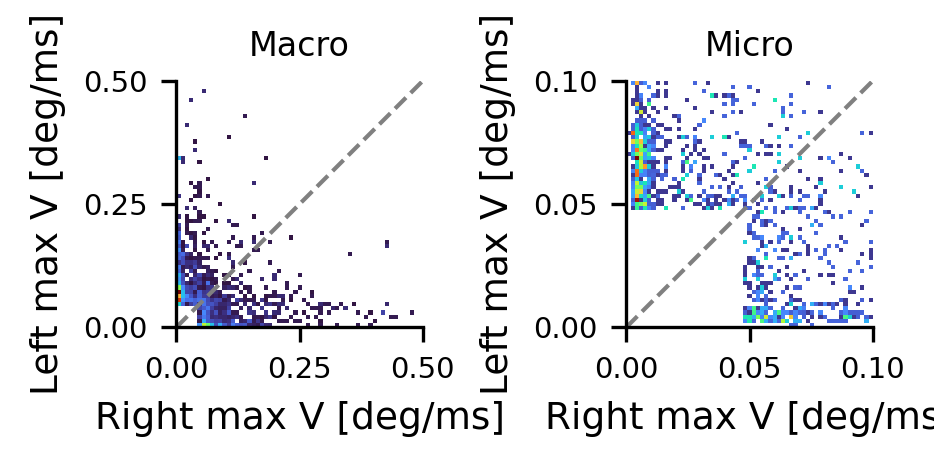

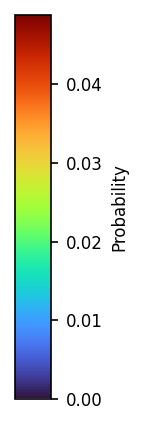

(<Figure size 900x510 with 2 Axes>,
 array([<Axes: title={'center': 'Macro'}, xlabel='Right max V [deg/ms]', ylabel='Left max V [deg/ms]'>,
        <Axes: title={'center': 'Micro'}, xlabel='Right max V [deg/ms]', ylabel='Left max V [deg/ms]'>],
       dtype=object))

In [43]:
t = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
export_path = rf'Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\show_monocular_saccades\{t}'
plot_right_vs_left_eye_hist2d_twopanels(
    all_saccade_collection.query('head_movement==False and animal !="PV_62" and animal !="PV_57"'),
    block_dict,
    export_path=export_path,
    iqr_multiplier=60, bins=60,
    macro_range=(0, 0.5), micro_range=(0, 0.1),
    macro_tick_list=[0,0.25,0.5],
    micro_tick_list=[0,0.05,0.1],
    event_mode="monocular",            # <— only keep events with NO contra onset nearby
    contra_event_window_ms=100,
    contra_sample_ms=51
)


100%|██████████| 11760/11760 [00:10<00:00, 1136.31it/s]


Points kept: 1036


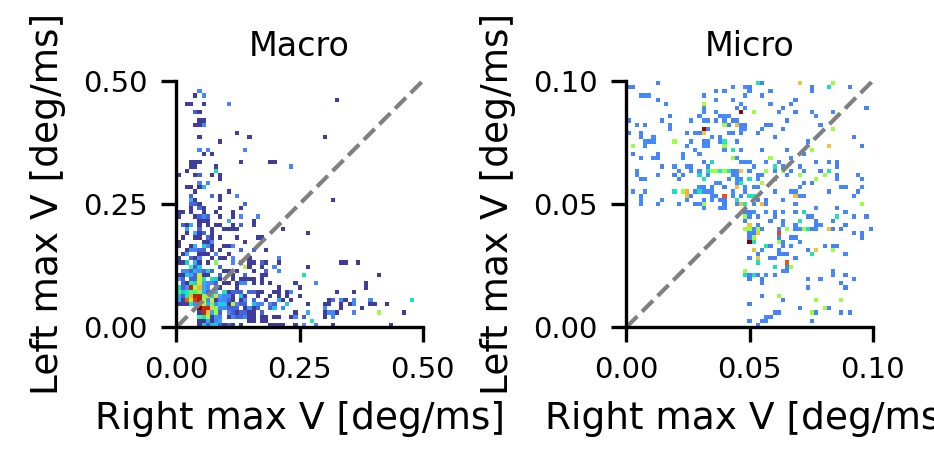

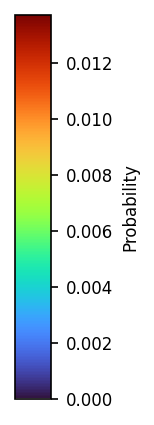

(<Figure size 900x510 with 2 Axes>,
 array([<Axes: title={'center': 'Macro'}, xlabel='Right max V [deg/ms]', ylabel='Left max V [deg/ms]'>,
        <Axes: title={'center': 'Micro'}, xlabel='Right max V [deg/ms]', ylabel='Left max V [deg/ms]'>],
       dtype=object))

In [40]:
t = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
export_path = rf'Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\show_monocular_saccades\{t}'
plot_right_vs_left_eye_hist2d_twopanels(
    all_saccade_collection.query('head_movement==True and animal !="PV_62" and animal !="PV_57"'),
    block_dict,
    export_path=None,
    iqr_multiplier=60, bins=60,
    macro_range=(0, 0.5), micro_range=(0, 0.1),
    macro_tick_list=[0,0.25,0.5],
    micro_tick_list=[0,0.05,0.1],
    event_mode="monocular",            # <— only keep events with NO contra onset nearby
    contra_event_window_ms=100,
    contra_sample_ms=51
)


In [38]:
# --- imports ---
import numpy as _np
import pandas as _pd
import matplotlib.pyplot as _plt
import datetime as _dt
import pathlib as _pl
import pickle as _pkl
from cycler import cycler

# =========================
# Universal color utilities
# =========================
COLOR_TEMPLATES = {
    # Colorblind-safe (Okabe–Ito)
    "okabeito": ["#0072B2", "#D55E00", "#009E73", "#CC79A7",
                 "#F0E442", "#56B4E9", "#E69F00", "#000000"],
    # Tableau-10 as an alternative
    "tableau10": [_plt.get_cmap("tab10")(i) for i in range(10)],
}

def build_color_map(labels, template="okabeito", custom=None, order=None):
    """
    Return dict {label -> color}. To keep animal colors stable across figures,
    pass a canonical 'order' (list of all animals) or pass an explicit color_map.
    """
    labs = list(order) if order is not None else list(labels)
    base = list(custom) if custom is not None else list(COLOR_TEMPLATES.get(template, COLOR_TEMPLATES["okabeito"]))
    return {lab: base[i % len(base)] for i, lab in enumerate(labs)}

def set_axes_color_cycle(ax, labels, color_map):
    ax.set_prop_cycle(cycler(color=[color_map[l] for l in labels]))

# =========================
# Angle helpers
# =========================
def _clean_angles_deg(series_like):
    """Return a 1D float64 numpy array of angles in [0, 360) with non-finite removed."""
    a = _pd.to_numeric(series_like, errors='coerce').to_numpy(dtype='float64')
    a = a[_np.isfinite(a)]
    # map into [0, 360)
    a = _np.mod(a, 360.0)
    return a

def _hist_deg(angles_deg, num_bins=36):
    """Histogram in degrees over [0, 360). Returns (density, bin_edges, bin_centers_deg)."""
    hist, edges = _np.histogram(angles_deg, bins=num_bins, range=(0.0, 360.0), density=True)
    centers = (edges[:-1] + edges[1:]) / 2.0
    return hist, edges, centers

def _preferred_axis_orientation_deg(density, centers):
    """
    Given a full [0, 360) histogram (density and centers), treat it as an AXIS distribution:

    - Fold the histogram into [0, 180) by summing opposite bins.
    - Return the center angle (in degrees, in [0, 180)) of the axis with maximal strength.

    This is axis-level (orientation of the line), not tied to whichever lobe is taller.
    """
    n = density.size
    if n % 2 != 0:
        raise ValueError(f"num_bins must be even for axis folding, got n={n}")

    half = n // 2
    # Fold opposite bins: [0..180) + [180..360)
    folded = density[:half] + density[half:]
    folded_centers = centers[:half]  # in [0, ~180)

    peak_idx = int(_np.argmax(folded))
    axis_center = float(folded_centers[peak_idx])  # in [0, 180)

    return axis_center

def _shortest_axis_rotation_deg(axis_center_deg):
    """
    Given an axis orientation in [0, 180) (line orientation),
    compute the SHORTEST rotation in [-90, 90] degrees that aligns
    this axis with the horizontal 0°/180° axis.

    We solve axis_center + rot ≡ 0 (mod 180) and choose the solution
    with minimal |rot|, which is guaranteed to lie within [-90, 90].
    """
    # Two candidates:
    # 1) Bring axis_center to 0°
    rot1 = -axis_center_deg
    # 2) Bring axis_center to 180°
    rot2 = 180.0 - axis_center_deg

    # Choose the one with smaller absolute rotation
    if abs(rot1) <= abs(rot2):
        return rot1
    else:
        return rot2

# ==========================================================
# Rotated per-eye saccade polar histogram (axis-based, shortest rotation)
# ==========================================================
def create_saccade_polar_histogram_rotated_per_eye(
    saccade_collection: _pd.DataFrame,
    figure_size=(5, 4),
    export_path=None,
    num_bins=36,
    baseline_prob=0.005,
    # --- color controls ---
    color_template="okabeito",   # "okabeito" | "tableau10"
    custom_colors=None,          # list of custom colors to override the template
    color_map=None,              # explicit mapping {'PV_62':'#...', ...} takes precedence
    font_family='Arial',
):
    """
    For each animal and each eye separately (L/R):

    1. Build a histogram of saccade angles over [0, 360).
    2. Treat the histogram as an AXIS distribution by folding opposite bins into [0, 180).
    3. Find the dominant axis orientation (0–180°).
    4. Compute the SHORTEST rotation (in [-90°, +90°]) that aligns this axis with the
       horizontal 0°/180° axis.
    5. Apply that rotation to the raw angles and plot a rotated polar histogram.

    Right-eye is plotted on the left subplot, left-eye on the right subplot.

    NOTE:
    -----
    Because we explicitly choose the SHORTEST rotation in ±90° at the *axis* level,
    we guarantee:
        - axis is horizontal,
        - |rotation| ≤ 90°,
    but we do *not* guarantee that the same original lobe ends up near 0° instead of 180°.
    That tradeoff (axis-level shortest rotation vs strict lobe identity) is unavoidable
    without an additional anatomical reference.
    """


    from pathlib import Path

    # Validate inputs
    required_cols = {'animal', 'eye', 'overall_angle_deg'}
    missing = required_cols.difference(set(saccade_collection.columns))
    if missing:
        raise ValueError(f"saccade_collection is missing required columns: {missing}")

    if num_bins % 2 != 0:
        raise ValueError(f"num_bins must be even for axis-based folding, got {num_bins}")

    # Animals (sorted for deterministic color assignment)
    animals = _np.array(sorted(saccade_collection['animal'].dropna().unique()))
    if animals.size == 0:
        raise ValueError("No animals found in 'animal' column.")

    # Build color mapping: explicit map > template/custom
    if color_map is None:
        cmap_built = build_color_map(animals, template=color_template, custom=custom_colors, order=animals)
    else:
        # allow partial overrides; fall back to template if missing
        fallback = build_color_map(animals, template=color_template, custom=custom_colors, order=animals)
        cmap_built = {a: color_map.get(a, fallback[a]) for a in animals}

    # Matplotlib font defaults
    _plt.rcParams['font.family'] = 'sans-serif'
    _plt.rcParams['font.sans-serif'] = [font_family]

    fig, axs = _plt.subplots(
        1, 2, figsize=figure_size, dpi=300, subplot_kw=dict(projection='polar')
    )

    rotation_catalog = {}  # store per animal/eye rotation (deg) applied
    per_eye_histograms = {}  # store histogram data for export

    # Helper to process one eye
    def _process_eye(ax, eye_label):
        nonlocal rotation_catalog, per_eye_histograms

        # Lock color cycle for consistent legend order
        set_axes_color_cycle(ax, animals, cmap_built)

        for animal in animals:
            df_eye = saccade_collection.query('animal == @animal and eye == @eye_label')

            # Clean angles to numeric degrees
            angles_deg = _clean_angles_deg(df_eye['overall_angle_deg'])
            if angles_deg.size == 0:
                continue

            # Base histogram
            base_density, base_edges, base_centers = _hist_deg(angles_deg, num_bins=num_bins)

            # --- AXIS-BASED ORIENTATION AND SHORTEST ROTATION ---
            axis_center = _preferred_axis_orientation_deg(base_density, base_centers)  # in [0, 180)
            rotation_deg = _shortest_axis_rotation_deg(axis_center)                    # in [-90, 90]
            rotation_catalog[(animal, eye_label)] = float(rotation_deg)

            # Apply rotation to the raw angles, re-histogram
            rotated_angles = _np.mod(angles_deg + rotation_deg, 360.0)
            density, edges, centers = _hist_deg(rotated_angles, num_bins=num_bins)

            # --- COLLECT HISTOGRAM DATA FOR EXPORT ---
            if animal not in per_eye_histograms:
                per_eye_histograms[animal] = {}

            per_eye_histograms[animal][eye_label] = {
                'angles': angles_deg.astype(_np.float32),  # Original angles array
                'counts': base_density.astype(_np.float32),  # Original histogram counts (density)
                'centers': base_centers.astype(_np.float32),  # Original bin centers
                'rotated_angles': rotated_angles.astype(_np.float32),  # Rotated angles array
                'rotated_counts': density.astype(_np.float32),  # Rotated histogram counts (density)
                'rotated_centers': centers.astype(_np.float32),  # Rotated bin centers
                'dominant_axis': float(axis_center),  # Dominant axis orientation
                'rotation_angle': float(rotation_deg),  # Rotation applied
                'n_saccades': len(angles_deg),  # Number of saccades
            }

            # Close the loop for polar plotting
            theta = _np.deg2rad(_np.r_[centers, centers[0]])
            rho   = _np.r_[density, density[0]]

            ax.plot(theta, rho, lw=1.2, color=cmap_built[animal],
                    label=f"{animal} (n={len(angles_deg)})")

        # Baseline shaded band
        theta_ring = _np.linspace(0, 2 * _np.pi, 512)
        ax.fill_between(theta_ring, 0, baseline_prob, alpha=0.15, color='gray', zorder=0)

        # Aesthetics
        ax.set_facecolor('white')
        ax.set_yticks([])   # cleaner polar
        ax.grid(False)
        ax.set_theta_zero_location('E')  # 0° to the right
        ax.set_theta_direction(-1)       # clockwise increases

        ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=6, frameon=False)

    # Right eye on left subplot; Left eye on right subplot
    _process_eye(axs[0], 'R')
    _process_eye(axs[1], 'L')
    axs[0].set_title("Right eye (rotated, axis-based)", fontsize=9, pad=10)
    axs[1].set_title("Left eye (rotated, axis-based)",  fontsize=9, pad=10)

    _plt.tight_layout()

    # Print rotations
    print("\n=== Axis-based rotation angles applied (degrees) ===")
    print(" (shortest rotation in [-90, 90] that aligns the dominant axis with 0°/180°)")
    for (animal, eye), rot in sorted(rotation_catalog.items(),
                                     key=lambda x: (x[0][0], x[0][1])):
        print(f"{animal:>10s}  Eye {eye}:  {rot:+7.2f}°")
    print("====================================================\n")

    # Optional export
    if export_path:
        ts = _dt.datetime.now().strftime("%Y_%m_%d_%H_%M")
        outdir = _pl.Path(export_path) / f"{ts}_Rotated_Saccade_Histogram_PerEye"
        outdir.mkdir(parents=True, exist_ok=True)

        pdf = outdir / f"{ts}_saccade_angles_histogram_rotated_pereye.pdf"
        _plt.savefig(pdf, bbox_inches='tight')

        with open(outdir / f"{ts}_per_eye_rotation_catalog.pkl", 'wb') as f:
            _pkl.dump(rotation_catalog, f)

        print("Exported histogram to", pdf)
        print("Saved rotation catalog to", outdir / f"{ts}_per_eye_rotation_catalog.pkl")

    # Export data for figure reproduction
    export_figure_2i_data(
        per_eye_histograms=per_eye_histograms,
        rotation_catalog=rotation_catalog,
        num_bins=num_bins,
        baseline_prob=baseline_prob,
        export_dir=outdir / 'fig_2i_data',
    )

    _plt.show()



=== Axis-based rotation angles applied (degrees) ===
 (shortest rotation in [-90, 90] that aligns the dominant axis with 0°/180°)
    PV_106  Eye L:   +35.00°
    PV_106  Eye R:    +5.00°
    PV_126  Eye L:    +5.00°
    PV_126  Eye R:   +15.00°
    PV_143  Eye L:   -15.00°
    PV_143  Eye R:   +25.00°
     PV_62  Eye L:   -15.00°
     PV_62  Eye R:   +25.00°

Exported histogram to Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\synced_saccade_polar_multi_animal_degrees\2026_01_08_22_14_Rotated_Saccade_Histogram_PerEye\2026_01_08_22_14_saccade_angles_histogram_rotated_pereye.pdf
Saved rotation catalog to Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\synced_saccade_polar_multi_animal_degrees\2026_01_08_22_14_Rotated_Saccade_Histogram_PerEye\2026_01_08_22_14_per_eye_rotation_catalog.pkl
Data for Figure 2i exported to Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\synced_saccade

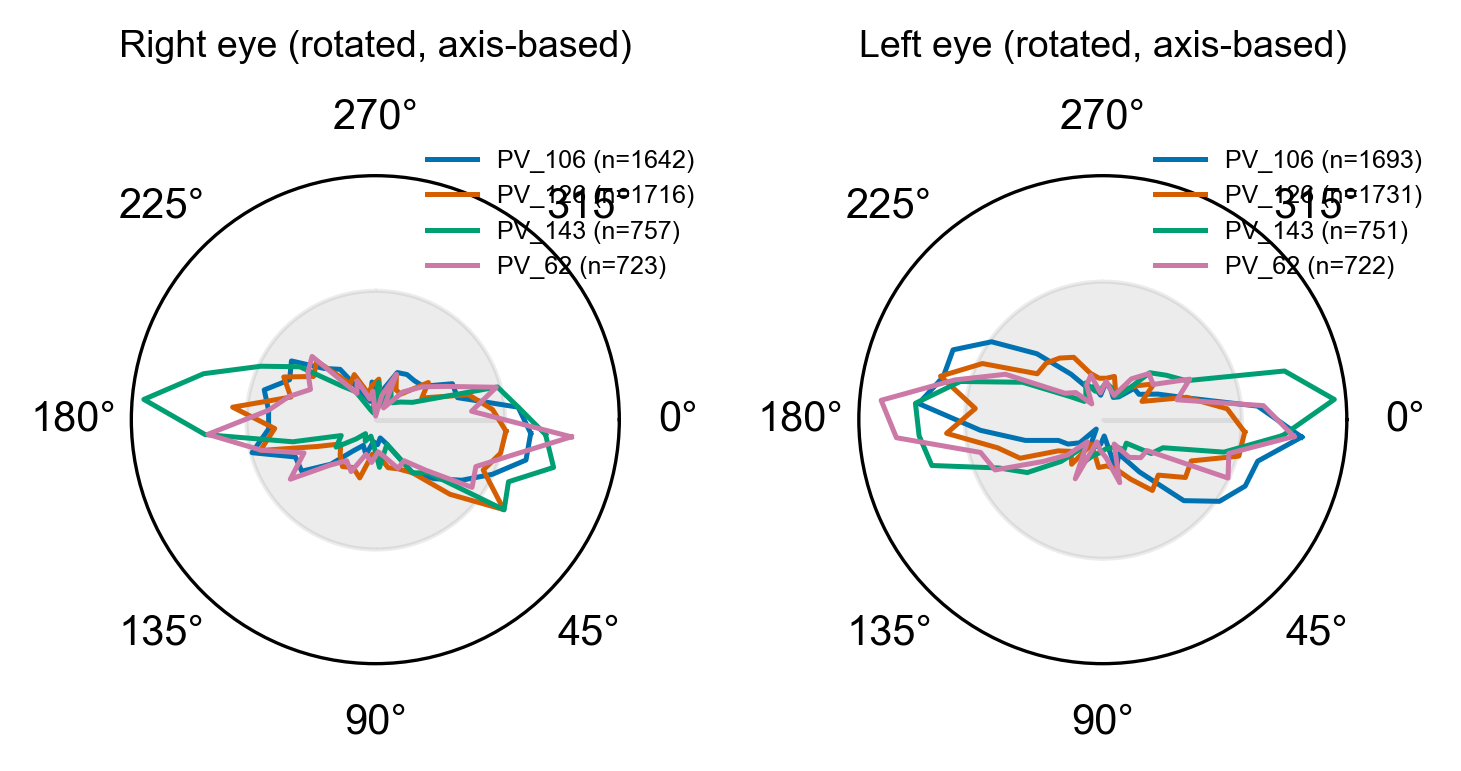

In [39]:
export_path = r'Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\synced_saccade_polar_multi_animal_degrees'
create_saccade_polar_histogram_rotated_per_eye(synced_saccade_collection.query('head_movement==True and animal !="PV_57"'), (5,4),export_path=export_path)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import os, datetime, pickle, tqdm
def plot_saccade_heatmaps_comparison_trajectories_angular(
    synced_saccades, non_synced_saccades, block_dict,
    export_path=None, nbins=200,
    global_min=-25, global_max=25,
    cmap=plt.cm.turbo, figsize=(4, 2.5),
    rotation_catalog=None   # {(animal,'L'|'R'): roll_deg CCW}
):


    def _rotate2d(x, y, deg):
        th = np.deg2rad(deg)
        c, s = np.cos(th), np.sin(th)
        xr = c * x - s * y
        yr = s * x + c * y
        return xr, yr

    def _per_eye_rotation(animal, eye):
        if rotation_catalog is None:
            return 0.0
        return float(rotation_catalog.get((animal, eye), 0.0))

    def extract_zeroed_points_ANG(saccades_df, eye):
        xs, ys = [], []
        df_eye = saccades_df[saccades_df['eye'] == eye]
        for _, row in tqdm.tqdm(df_eye.iterrows(), total=len(df_eye), desc=f"Collect {eye} (ang)"):
            block = block_dict.get(f"{row['animal']}_block_{row['block']}")
            if block is None:
                continue
            eye_df = block.left_eye_data if eye == 'L' else block.right_eye_data
            if not {'k_phi','k_theta','ms_axis'}.issubset(eye_df.columns):
                # fall back or skip if angles not present
                continue

            seg = eye_df[(eye_df['ms_axis'] >= row['saccade_on_ms']) &
                         (eye_df['ms_axis'] <= row['saccade_off_ms'])]
            if seg.empty:
                continue

            phi0   = seg['k_phi'].iloc[0]
            theta0 = seg['k_theta'].iloc[0]
            dphi   = (seg['k_phi']   - phi0).to_numpy(float)
            dtheta = (seg['k_theta'] - theta0).to_numpy(float)

            # Apply Blender per-eye roll (CCW in math coords)
            rot_deg = _per_eye_rotation(row['animal'], eye)
            dphi_r, dtheta_r = _rotate2d(dphi, dtheta, rot_deg)

            xs.extend(dphi_r.tolist())
            ys.extend(dtheta_r.tolist())

        return np.asarray(xs, float), np.asarray(ys, float)

    # Collect angular displacements (degrees)
    r_x_s, r_y_s   = extract_zeroed_points_ANG(synced_saccades, 'R')
    l_x_s, l_y_s   = extract_zeroed_points_ANG(synced_saccades, 'L')
    r_x_ns, r_y_ns = extract_zeroed_points_ANG(non_synced_saccades, 'R')
    l_x_ns, l_y_ns = extract_zeroed_points_ANG(non_synced_saccades, 'L')

    export_figure_2h_data(
    synced_saccades={
        'R': (r_x_s, r_y_s),
        'L': (l_x_s, l_y_s)
    },
    non_synced_saccades={
        'R': (r_x_ns, r_y_ns),
        'L': (l_x_ns, l_y_ns)
    },
    rotation_catalog=rotation_catalog,
    nbins=nbins,
    global_min=global_min,
    global_max=global_max,
    export_dir=pathlib.Path(export_path) / 'fig_2h_data'
)

    def evaluate_kde(x, y):
        if len(x) == 0 or len(y) == 0:
            return None, None, None
        k  = gaussian_kde(np.vstack([x, y]).astype(float))
        xi, yi = np.mgrid[global_min:global_max:nbins*1j,
                          global_min:global_max:nbins*1j]
        zi = k(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
        zi /= np.sum(zi)
        return xi, yi, zi

    xi_r_s, yi_r_s, zi_r_s   = evaluate_kde(r_x_s,  r_y_s)
    xi_l_s, yi_l_s, zi_l_s   = evaluate_kde(l_x_s,  l_y_s)
    xi_r_ns, yi_r_ns, zi_r_ns = evaluate_kde(r_x_ns, r_y_ns)
    xi_l_ns, yi_l_ns, zi_l_ns = evaluate_kde(l_x_ns, l_y_ns)

    # Shared color scale
    all_zi = [z for z in [zi_r_s, zi_l_s, zi_r_ns, zi_l_ns] if z is not None]
    vmin, vmax = (min(z.min() for z in all_zi), max(z.max() for z in all_zi)) if all_zi else (0, 1)

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=figsize, dpi=300, sharey=True, sharex=True)

    def plot_heatmap(ax, xi, yi, zi, title=None):
        if zi is not None:
            ax.imshow(
                zi.T, extent=[global_min, global_max, global_min, global_max],
                origin='lower', cmap=cmap, vmin=vmin, vmax=vmax
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=8, transform=ax.transAxes)
        ax.set_title(title, fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.set_aspect('equal', 'box')

    plot_heatmap(axes[0,0], xi_r_s,  yi_r_s,  zi_r_s)#,  'Right (Synced)')
    plot_heatmap(axes[0,1], xi_l_s,  yi_l_s,  zi_l_s)#,  'Left (Synced)')
    plot_heatmap(axes[1,0], xi_r_ns, yi_r_ns, zi_r_ns)#, 'Right (Non-Synced)')
    plot_heatmap(axes[1,1], xi_l_ns, yi_l_ns, zi_l_ns)#, 'Left (Non-Synced)')

    # Label axes to reflect anatomical frame (in degrees)
    # axes[1,0].set_xlabel("ear → nostril")
    # axes[1,1].set_xlabel("nostril → ear")
    # axes[0,0].set_ylabel("dorsal ↔ ventral")
    # axes[1,0].set_ylabel("dorsal ↔ ventral ")

    plt.tight_layout()
    # Export
    if export_path is not None:
        timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
        full_export_path = os.path.join(export_path, f"saccade_heatmaps_trajectories_{timestamp}")
        os.makedirs(full_export_path, exist_ok=True)
        pdf_file = os.path.join(full_export_path, "saccade_heatmaps_comparison_trajectories.pdf")
        fig.savefig(pdf_file, format='pdf', bbox_inches='tight', dpi=300)
        data_file = os.path.join(full_export_path, "saccade_trajectories_data.pkl")
        with open(data_file, 'wb') as f:
            pickle.dump({
                'synced': {'R': (r_x_s, r_y_s), 'L': (l_x_s, l_y_s)},
                'non_synced': {'R': (r_x_ns, r_y_ns), 'L': (l_x_ns, l_y_ns)},
                'rotation_catalog': rotation_catalog
            }, f)
        print(f"Exported plot and data to: {full_export_path}")
    plt.show()


Collect L (ang): 100%|██████████| 527/527 [00:00<00:00, 1185.73it/s]


Data for Figure 2h exported to Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\saccade_heatmaps_degree_verified\fig_2h_data\figure_2h.pickle
Exported plot and data to: Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\saccade_heatmaps_degree_verified\saccade_heatmaps_trajectories_2026_01_08_21_20_18


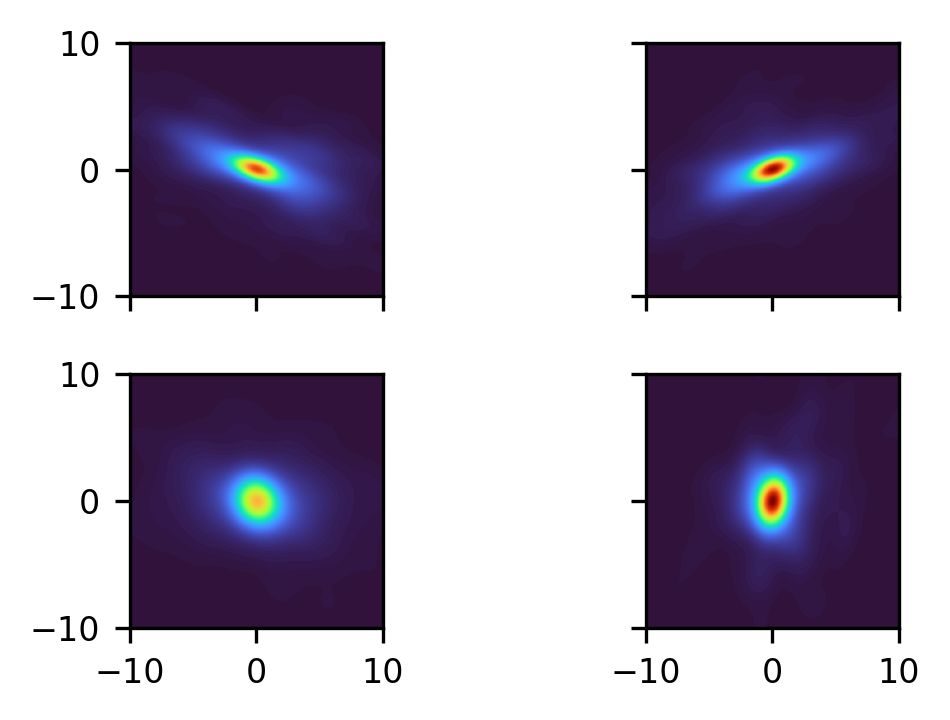

In [35]:
export_path = r'Z:\Nimrod\Paper_Figures\2024_Personalized_headstage_eye_tracking\Figure_3\materials\saccade_heatmaps_degree_verified'
plot_saccade_heatmaps_comparison_trajectories_angular(
    synced_saccade_collection.query('animal=="PV_143"'),
    non_synced_saccade_collection.query('animal=="PV_143"'),
    block_dict,
    export_path=export_path,
    nbins=200, global_min=-10, global_max=10,
    cmap=plt.cm.turbo, figsize=(4, 2.5),
    rotation_catalog=None   # <-- add this
)